## code to load in all datasets, create unique id's for them, then combine into single dataframe

List of datasets:
- SeaBASS (by region)
    - SB_chl_na.xlsx
- CalCOFI
    - calcofi_chl_qc.xlsx
- Gloria
    - ch
- HOTS
    - hots_chl_qc.xlsx
- IOOS
    - ioos_chl_qc.xlsx(note:this is reduced to single day ones)
- WOD (1, 2, Ecomon)
    - wod_chl_na.xlsx
- BCO-DMO
    - bco_dmo_chl_qc.xlsx
- AquaMatch
    - aquamatch_chl_na.xlsx
- GLOBEC
    - globec_chl_qc.xlsx

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from datetime import datetime
import os
from matplotlib import ticker
import datetime as dt
import plotly.express as px
import cmocean as cm
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import time
import matplotlib.ticker as mticker
import xarray as xr
import csv


In [ ]:
#ALL dataframes should have experiment, data_type (if possible), affiliations, investigators, contact, url
#IF the dataset does not have experiemnent, remove?? only once i concat

# Chlorophyll ID column and final concatination

In [2]:
CalCOFI = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\calcofi_chl_qc.xlsx')
CalCOFI = CalCOFI.rename(columns={'identifier_product_doi':'DOI_url'})
CalCOFI['experiment']='CalCOFI'
CalCOFI['affiliations']='NOAA Fisheries, Scripps, CDFW'
CalCOFI['data_type']='bottle'

In [3]:
gloria_chl = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\GLORIA_chl_na.xlsx')
gloria_chl['datetime'] = pd.to_datetime(gloria_chl['datetime'])

In [4]:
seabass = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\SB_chl_na.xlsx')
seabass = seabass.rename(columns={'identifier_product_doi':'DOI_url','decision':'data_type_flag'})

#Calcofi has some unique data on seabass, so only the ones that overlap with calcofi, not all seabass.experiment = CalCOFI
sb_calc = CalCOFI[['datetime', 'lat', 'lon','depth']] #reduce to datetime, lat, lon, and depth for  matching
seabass['depth'] =seabass['depth'].astype('int64') #to match datatype of calcofi
#merge the two dataframes on similar columns
seabass = seabass.merge(sb_calc[['datetime', 'lat', 'lon','depth']], on=['datetime', 'lat', 'lon','depth'], how='left', indicator=True) #all calcofi data with seabass indicator
seabass =  seabass[seabass['_merge'] != 'both'] #remove rows where _merge has both
seabass=seabass[['datetime', 'lat', 'lon', 'chl', 'chl_a', 'depth', 'experiment', 'data_type', 'station', 'affiliations', 'investigators', 'contact',
       'cruise', 'DOI_url', 'HPLC', 'triplicate', 'data_type_flag']]
seabass['source']='SeaBASS'

In [5]:
#now that calcofi data has been removed, remove any repeated gloria data
gloria_sb = gloria_chl[gloria_chl['DOI_url'] !='https://doi.pangaea.de/10.1594/PANGAEA.948492'] #remove any data without seabass doi
gloria_sb=gloria_sb.rename(columns={"DOI_url": "doi_url"}) #temporary doi to match seabass temporary doi 
gloria_sb=gloria_sb[['datetime', 'depth','doi_url','lat', 'lon','chl']]

seabass['datetime'] = pd.to_datetime(seabass['datetime'])
seabass_test=seabass.copy()
seabass_test['doi_url'] = seabass_test['DOI_url'].str.lower() #all lowercase to match with gloria naming convention 

test2 = pd.merge(gloria_sb, seabass_test, on=['datetime', 'doi_url','lat', 'lon','chl'], how='right',indicator=True).reset_index(drop=True)
seabass1 =  test2[test2['_merge'] != 'both'] #remove rows where _merge has both
seabass1 = seabass1[['datetime', 'lat', 'lon', 'chl', 'chl_a', 'depth_y', 'experiment', 'data_type', 'station', 'affiliations', 'investigators', 'contact',
      'source', 'cruise', 'DOI_url', 'HPLC', 'triplicate', 'data_type_flag']]
seabass = seabass1.rename(columns={'depth_y':'depth'})

In [6]:
#add 2025 data 
seabass2 = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\SB_chl_2025.xlsx')
seabass2 = seabass2.rename(columns={'decision':'data_type_flag'})
seabass2=seabass2[['datetime', 'lat', 'lon', 'chl', 'chl_a', 'depth', 'experiment', 'data_type', 'station', 'affiliations', 'investigators', 'cruise', 
                   'HPLC', 'triplicate', 'data_type_flag']]
seabass2['source']='SeaBASS'

In [7]:
HOTS = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\hots_chl_qc.xlsx')
HOTS = HOTS.rename(columns={'url':'DOI_url'})
HOTS['data_type']='bottle'

In [8]:
IOOS = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\ioos_chl_qc2.xlsx')
IOOS = IOOS.rename(columns={'url':'DOI_url','Institution':'affiliations','date':'datetime','decision':'data_type_flag'})
IOOS=IOOS[['datetime', 'lat', 'lon', 'chl', 'depth', 'source', 'affiliations', 'DOI_url', 'experiment', 'HPLC', 'triplicate','data_type_flag']] 
IOOS = IOOS[IOOS['datetime'] <= '2026-01-01'] #only keep 2025 data
#remove 'Dataset ID' since repeat of experiment 

In [9]:
bco = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\bco_dmo_chl_qc.xlsx')
bco = bco.rename(columns={'url':'DOI_url'})

In [10]:
#wod doesn't always have experiment, but always has accession number i.e. NODC accession number so use that instead 
wod = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\wod_chl_na.xlsx')
wod['source'] = 'WOD'
wod['DOI_url'] = 'https://www.ncei.noaa.gov/access/world-ocean-database-select/dbsearch.html'
wod=wod[['datetime', 'lat', 'lon', 'chl', 'depth', 'cruise','affiliations', 'source','investigators', 'HPLC', 'triplicate','decision', 'accession number']]
wod = wod.rename(columns={'accession number':'experiment','decision':'data_type_flag'})

In [11]:
aqua = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\aquamatch_chl_na.xlsx')
aqua = aqua.rename(columns={'url':'DOI_url'})
aqua['experiment']='AquaMatch'

In [12]:
globec = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\globec_chl_qc.xlsx')
globec = globec.rename(columns={'url':'DOI_url'})

In [13]:
seamap = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\seamap_chl.xlsx')
seamap = seamap.dropna(subset=['depth'])
seamap = seamap[['datetime', 'lat', 'lon', 'chl','station','cruise', 'depth','source', 'DOI_url', 'experiment', 'investigators',
       'affiliations', 'HPLC', 'triplicate']]
seamap = seamap[seamap['depth'] <=150]

In [19]:
arctic = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\arctic_pigment_chl.xlsx')
arctic = arctic.rename(columns={'url':'DOI_url','contact':'investigators','affiliation':'affiliations'})
arctic=arctic[['datetime', 'lat', 'lon', 'depth','chl_a', 'experiment', 'DOI_url', 'triplicate', 'HPLC', 'source', 'investigators', 'affiliations']]
arctic = arctic.dropna(subset=['depth'])
arctic = arctic.dropna(subset=['chl_a'])
arctic['source'] = 'Pan-Arctic'
arctic = arctic[arctic['depth'] <=150]

In [20]:
CIOOS = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\CIOOS_chl.xlsx')
CIOOS=CIOOS[['cruise', 'station', 'datetime', 'lat', 'lon', 'depth', 'chl', 'experiment', 'investigators', 'affiliations', 'DOI_url', 'HPLC',
       'triplicate', 'chl_a']]
CIOOS['source'] = 'CIOOS'

In [21]:
dfs=[seabass,seabass2,aqua,bco,CalCOFI,globec,HOTS,IOOS,wod,gloria_chl,seamap,arctic,CIOOS]
all_chl = pd.concat(dfs).reset_index(drop=True)
all_chl = all_chl.dropna(subset=['chl', 'chl_a'], how='all')
all_chl = all_chl.dropna(subset=['datetime'], how='all') #if no datetime, remove

#so usually, HPLC chl is in the chl_a column. HOwever, sometimes a project lables hplc chlorophyll as chl (NOT chl_a). 
#so, to keep it consistant, what i need to do is 1. IF HPLC is flagged as good (0), 2. if chl_a is empty, THEN populate with the value in chl.
#that way, we retain what the original data source says, but it makes the HPLC data more consistant. Sometimes chl and chl_a are both recorded also
all_chl.loc[(all_chl['HPLC']== 0) & (all_chl['chl_a'].isnull()), 'chl_a'] = all_chl['chl']

In [22]:
#remove all negative values from column
condition_A = (all_chl['chl'] >= 0) | (all_chl['chl'].isnull())
condition_B = (all_chl['chl_a'] >= 0) | (all_chl['chl_a'].isnull())
all_chl = all_chl[condition_A & condition_B]

In [24]:
#first, create a temporary column that has the xperiment names but without special charecters (_,-,',(,[)
all_chl['temp_exp'] = all_chl['experiment'].str.replace('_', '', regex=False)
all_chl['temp_exp'] = all_chl['temp_exp'].str.replace('-', '', regex=False)
all_chl['temp_exp'] = all_chl['temp_exp'].str.replace(' ', '', regex=False)
all_chl['temp_exp'] = all_chl['temp_exp'].str.replace('(', '', regex=False)
all_chl['temp_exp'] = all_chl['temp_exp'].str.replace(')', '', regex=False)
all_chl['temp_exp'] = all_chl['temp_exp'].str.replace('[', '', regex=False)
all_chl['temp_exp'] = all_chl['temp_exp'].str.replace(']', '', regex=False)

In [25]:
all_chl['ID_code'] = all_chl['source'].astype(str) + '_' + all_chl['temp_exp'].astype(str) + '_' + all_chl['datetime'].dt.strftime('%Y%m%d-%H%M%S').astype(str) + '_' + all_chl['lat'].astype(str) + '_' + all_chl['lon'].astype(str) +'_' + all_chl['depth'].astype(str)+'m'
#add sequential sample number to repeated id tags
all_chl['ID_code'] = all_chl['ID_code'] + '_' + all_chl.groupby('ID_code').cumcount().astype(str)

In [26]:
shp = gpd.read_file(r'C:\Users\gianna.milton\Documents\Python\Shapefiles\combined_coastline.shp')
gdf = gpd.GeoDataFrame(all_chl, geometry=gpd.points_from_xy(all_chl.lon, all_chl.lat), crs="EPSG:4269")
gdf = gdf.to_crs(shp.crs)
all_chl = gpd.sjoin(gdf, shp, how="inner", predicate="within")
columns_to_drop = ['geometry', 'index_right', 'merge_id']
all_chl = all_chl.drop(columns=columns_to_drop)
all_chl= all_chl.reset_index(drop=True)

In [27]:
all_chl=all_chl[['ID_code','datetime', 'lat', 'lon', 'chl', 'chl_a', 'depth', 'experiment', 'station', 'affiliations', 'investigators', 'contact',
       'cruise', 'DOI_url', 'HPLC', 'triplicate', 'data_type_flag', 'source', 'cast']]

In [28]:
all_chl.to_excel('all_chl.xlsx', index = False)


In [29]:
all_chl.source.value_counts()

source
SeaBASS       248214
IOOS          147213
CalCOFI        88942
WOD            55014
SEAMAP         54200
AquaMatch      49944
CIOOS          34433
BCO-DMO        17025
HOTS           10058
Pan-Arctic      2582
GLORIA           787
Name: count, dtype: int64

### chlorophyll plots and visualization

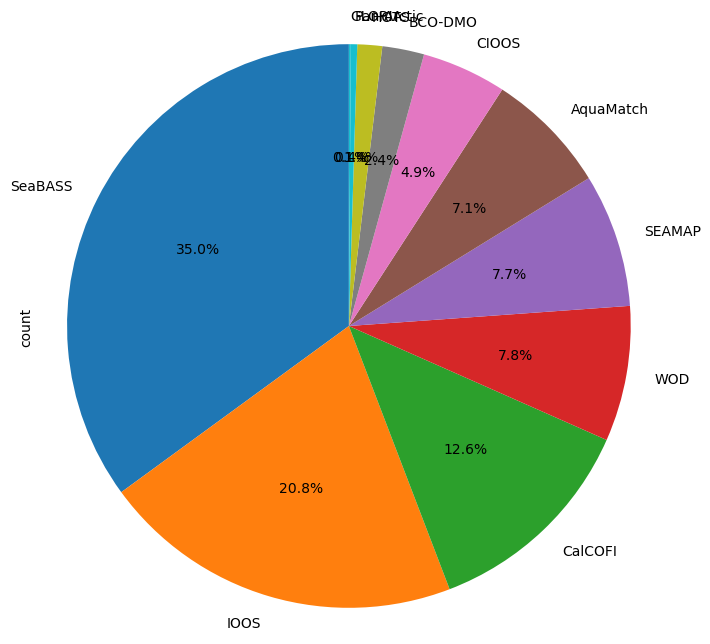

In [30]:
category_counts = all_chl['source'].value_counts() 
plt.figure(figsize=(8, 8)) # Optional: set the figure size
category_counts.plot.pie(autopct='%1.1f%%', startangle=90, cmap='tab10')
plt.axis('equal') 
plt.show()

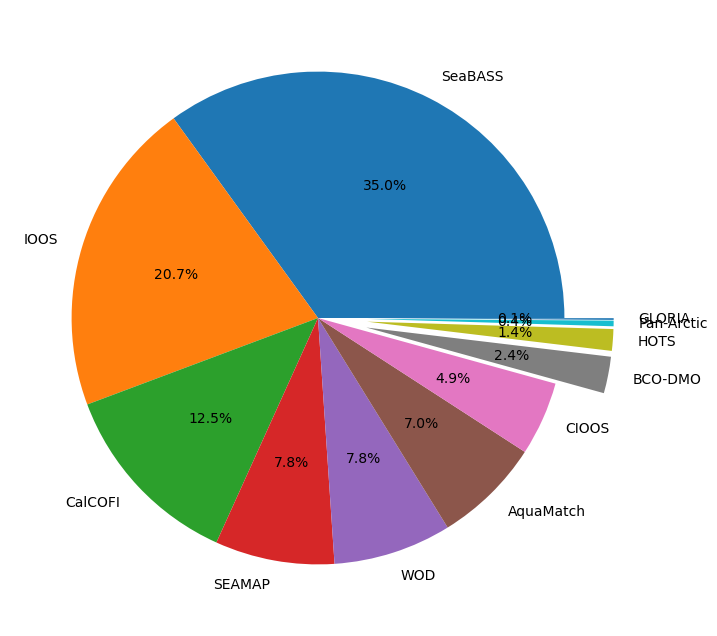

In [25]:
category_counts=category_counts.reset_index()
explode = (0, 0,0,0, 0, 0, 0, 0.2, 0.2, 0.2, 0.2)
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(category_counts['count'], explode=explode,labels=category_counts['source'], autopct='%1.1f%%', labeldistance=1.1)
plt.show()

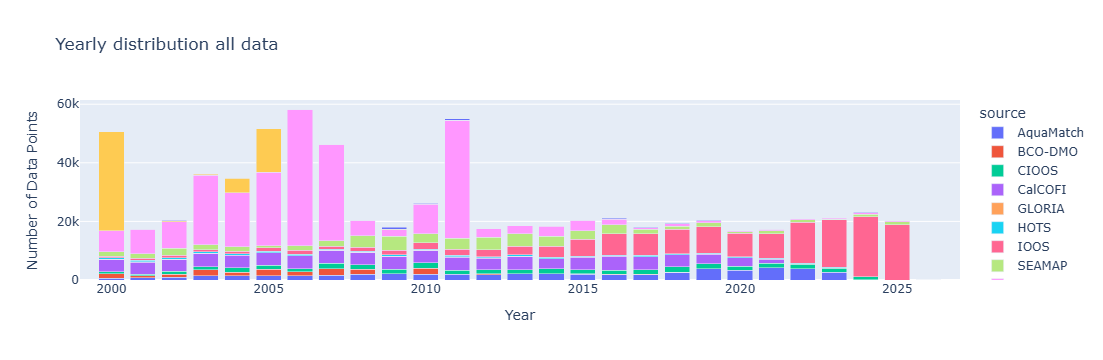

In [31]:
year_test=all_chl.copy()
year_test['datetime'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['datetime'].dt.year
grouped = year_test.groupby(['year', 'source']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(
    grouped,
    x='year',
    y='DataPoints',
    color='source',
    title='Yearly distribution all data',
    labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

C:\Users\gianna.milton\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\gianna.milton\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


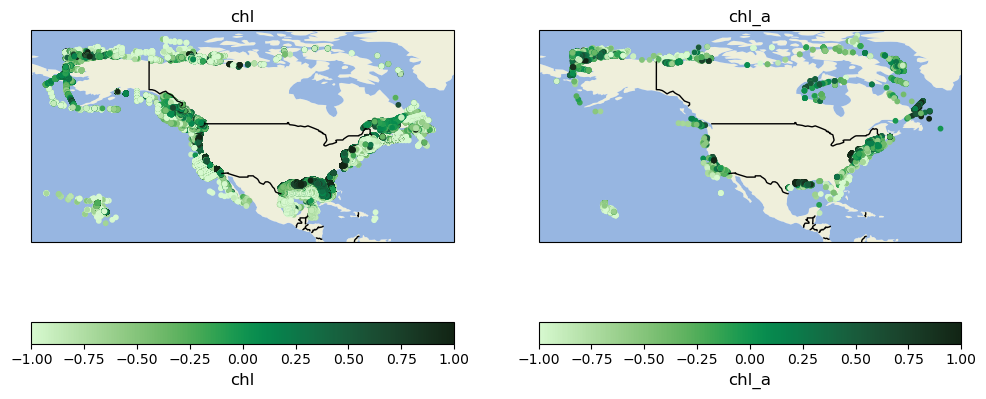

In [45]:
year_test['log_chl']=np.log10(year_test['chl'])
year_test['log_chl_a']=np.log10(year_test['chl_a'])

fig=plt.figure(figsize=(12, 7))
axs1=fig.add_subplot(1,2,1,projection= cartopy.crs.PlateCarree())
axs1.add_feature(cfeature.LAND)
axs1.add_feature(cfeature.OCEAN)
axs1.add_feature(cfeature.BORDERS)
im=axs1.scatter(year_test.lon,year_test.lat,c=year_test.log_chl,cmap=cmo.algae,s=10,vmin=-1, vmax=1)
axs1.set_title('chl')
axs1.set_extent([-180, -40, 10, 80], crs=ccrs.PlateCarree())
cb=fig.colorbar(im,ax=axs1,orientation='horizontal')
cb.set_label('chl',fontsize=12)

axs2=fig.add_subplot(1,2,2,projection= cartopy.crs.PlateCarree())
axs2.add_feature(cfeature.LAND)
axs2.add_feature(cfeature.OCEAN)
axs2.add_feature(cfeature.BORDERS)
im=axs2.scatter(year_test.lon,year_test.lat,c=year_test.log_chl_a,cmap=cmo.algae,s=10,vmin=-1, vmax=1)
axs2.set_title('chl_a')
cb=fig.colorbar(im,ax=axs2,orientation='horizontal')
cb.set_label('chl_a',fontsize=12)
axs2.set_extent([-180, -40, 10, 80], crs=ccrs.PlateCarree())
#,cbar_kwargs={'ticks': [ -1, -0.5,0, 0.5, 1],'format': mticker.FixedFormatter([ 0.1, 0.3, 1, 3,10])}
#im=west_coastchl.plot(ax=axes[1],cmap='viridis',vmin=-1, vmax=1,cbar_kwargs={'ticks': [ -1, -0.5,0, 0.5, 1],'format': mticker.FixedFormatter([ 0.1, 0.3, 1, 3,10])})


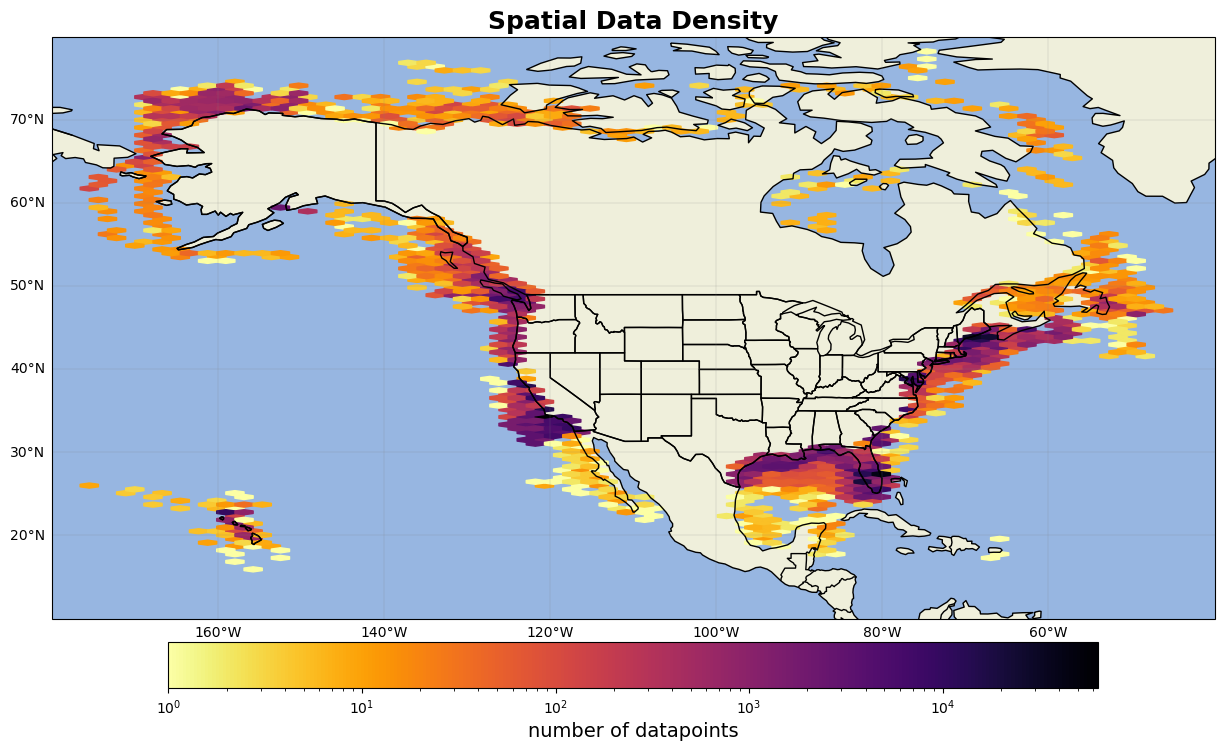

In [32]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(year_test.lon, year_test.lat, gridsize=150, cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='horizontal', pad=0.02, shrink=0.8)
cb.set_label('number of datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_extent([-180, -40, 10, 80], crs=ccrs.PlateCarree())

ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()

# RRS

In [2]:
gloria = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\GLORIA_rrs_na.xlsx')
gloria['datetime'] = pd.to_datetime(gloria['datetime'])
gloria['source']='GLORIA'
gloria = gloria[gloria['datetime'] >= '2000-01-01'] #only want data from 2000 on for this algorithm 
gloria = gloria.dropna(subset=['depth'])

In [3]:
seabass = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\SB_rrs_na.xlsx')
seabass = seabass.rename(columns={'identifier_product_doi':'DOI_url'})
seabass=seabass[['datetime', 'lon', 'lat', 'DOI_url', 'affiliations', 'investigators', 'contact', 'experiment', 'cruise',
       'station', 'rrs', 'wavelength', 'depth']]
seabass['source']='SeaBASS'
seabass['datetime'] = pd.to_datetime(seabass['datetime'])


In [4]:
#remove GLORIA data from Seabass 
gloria_sb = gloria[gloria['DOI_url'] !='https://doi.pangaea.de/10.1594/PANGAEA.948492'] #only gather data that has seabass doi
gloria_sb=gloria_sb.rename(columns={"DOI_url": "doi_url"})
gloria_sb=gloria_sb[['datetime', 'doi_url','lat', 'lon','wavelength','rrs']]

seabass_test=seabass.copy()
seabass_test['doi_url'] = seabass_test['DOI_url'].str.lower()

test2 = pd.merge(gloria_sb, seabass_test, on=['datetime', 'doi_url','lat', 'lon','wavelength','rrs'], how='right',indicator=True).reset_index(drop=True)
#seabass data has some wavelengths that gloria does not i.e., 10.5067/seabass/2009oct_chesapeake/data001 has wavelengths above 800 on seabass not on gloria
seabass =  test2[test2['_merge'] != 'both'] #remove rows where _merge has both
seabass=seabass[['datetime', 'lat', 'lon', 'wavelength', 'rrs','source', 'DOI_url', 'affiliations', 'investigators', 'contact', 'experiment', 
                 'cruise','station', 'depth']]

In [5]:
dfs=[seabass,gloria]
all_rrs = pd.concat(dfs).reset_index(drop=True)
all_rrs = all_rrs[all_rrs['depth'] <=150]
all_rrs = all_rrs.dropna(subset=['depth'], how='all') #if no datetime, remove

In [6]:
all_vars = ['source', 'datetime', 'lon', 'lat', 'depth', 'rrs', 'wavelength',  'experiment', 'DOI_url', 'affiliations', 'investigators', 'contact', 
            'cruise', 'station']
all_rrs = all_rrs.drop_duplicates(subset=all_vars, keep='first')
all_rrs['datetime'] = pd.to_datetime(all_rrs['datetime'])

In [84]:
#so these id tags will be different,, since there can be multiple rows with identical datetime, lon, lat, and depth but unique wavelength
#what i should do i think it first turn the dataframe into rrs_### and create id tags based on that and see what the value_counts is 

In [7]:
def long_to_wide(df):
    """
    Transforms long format to wide format (rrs_###) without averaging duplicates,
    preserving rows even if they have missing metadata (NaNs).
    """
    id_vars = ['source', 'datetime', 'lon', 'lat', 'depth', 'experiment', 'DOI_url', 'affiliations', 'investigators', 'contact', 'cruise', 'station']
    # temporarily fill NaNs with a string so pivot_table doesn't drop them
    df[id_vars] = df[id_vars].fillna('MISSING_DATA')
    
    #group by the full id_vars list to ensure the counter perfectly aligns
    df['temp_counter'] = df.groupby(id_vars + ['wavelength']).cumcount()
    df_wide = df.pivot_table(index=id_vars + ['temp_counter'], columns='wavelength',  values='rrs')
    new_column_names = [f"rrs_{str(col)}" for col in df_wide.columns]
    df_wide.columns = new_column_names
    df_wide = df_wide.reset_index()
    df_wide = df_wide.drop(columns=['temp_counter'])
    return df_wide

test = long_to_wide(all_rrs)

In [8]:
test['temp_exp'] = test['experiment'].str.replace('_', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace('-', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace(' ', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace('(', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace(')', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace('[', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace(']', '', regex=False)

test['ID_code'] = (test['source'].astype(str) + '_' + test['temp_exp'].astype(str) + '_' + test['datetime'].dt.strftime('%Y%m%d-%H%M%S').astype(str) + '_' + 
    test['lat'].astype(str) + '_' + test['lon'].astype(str) + '_' + test['depth'].astype(str) + 'm')
test['ID_code'] = test['ID_code'] + '_' + test.groupby('ID_code').cumcount().astype(str)

In [ ]:
#sometimes there are duplicates/ repeated data that have different rrs values. so add an id tag to THESE and then 
#turn back into long format df, that way these 3 ids will repeat for 9 rows, but they'll all relate to the same datetime lat lon ect without a unique code
#per wavelength value. 
#test2=test[(test['experiment']=='Bold_EPAHypoxia') & (test.lat ==29.532833)]
#test2.to_excel('test2.xlsx', index = False)

In [9]:
#turn back into rrs column adn wavelength column
rrs_cols = [col for col in test.columns if col.startswith('rrs_')]
id_vars_melt = ['source', 'datetime', 'lon', 'lat', 'depth', 'experiment', 'DOI_url', 'affiliations', 'investigators', 'contact', 'cruise', 'station', 'ID_code']

df_long = test.melt(id_vars=id_vars_melt, value_vars=rrs_cols,var_name='raw_wavelength',value_name='rrs')
df_long['raw_wavelength'] = df_long['raw_wavelength'].str.replace('rrs_', '')
df_long['wavelength'] = pd.to_numeric(df_long['raw_wavelength'])
df_long = df_long.drop(columns=['raw_wavelength'])
df_long = df_long.dropna(subset=['rrs'])
df_long[id_vars_melt] = df_long[id_vars_melt].replace('MISSING_DATA', np.nan)
df_long=df_long.reset_index(drop=True)

In [10]:
print(len(df_long))
print(len(all_rrs))

971912
971912


In [11]:
df_long.to_excel('all_rrs.xlsx', index = False)


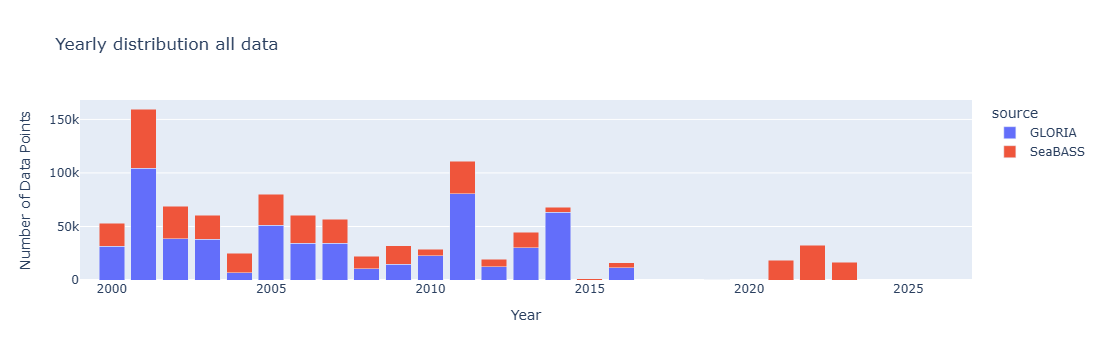

In [39]:
year_test=df_long.copy()
year_test['datetime'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['datetime'].dt.year
grouped = year_test.groupby(['year', 'source']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(
    grouped,
    x='year',
    y='DataPoints',
    color='source',
    title='Yearly distribution all data',
    labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

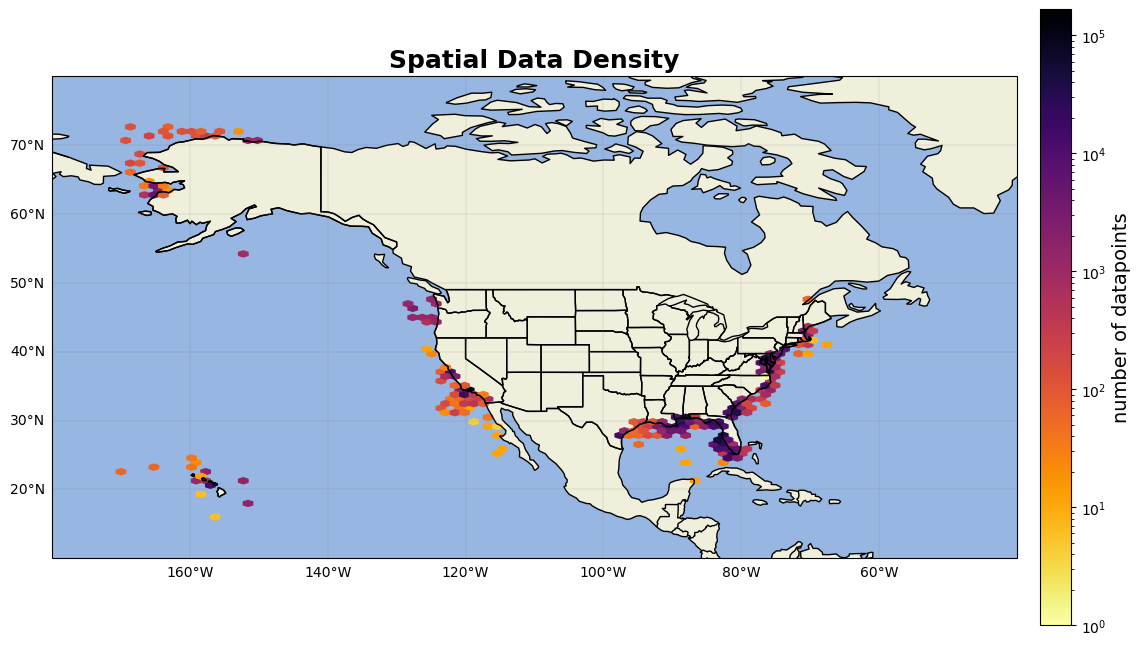

In [40]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(df_long.lon, df_long.lat, gridsize=75, cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cb.set_label('number of datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_extent([-180, -40, 10, 80], crs=ccrs.PlateCarree())

ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()

# CDOM

In [8]:
seabass = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\SB_cdom_na.xlsx')
seabass = seabass.rename(columns={'identifier_product_doi':'DOI_url'})
seabass=seabass[['datetime', 'lon', 'lat', 'DOI_url', 'affiliations','investigators', 'experiment', 'cruise', 'station', 'depth','cdom']]
seabass['source']='SeaBASS'

In [9]:
ioos = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\ioos_cdom_na.xlsx')
ioos = ioos.rename(columns={'url':'DOI_url','Institution':'affiliations','date':'datetime','Dataset ID':'station'})
ioos=ioos[['datetime', 'lat', 'lon',  'cdom', 'depth', 'source', 'affiliations', 'DOI_url', 'experiment','station']]

In [10]:
bcodmo = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\bco_dmo_cdom_qc.xlsx')
bcodmo = bcodmo.rename(columns={'url':'DOI_url'})
bcodmo=bcodmo[['datetime', 'lat', 'lon', 'depth', 'cruise', 'cdom', 'experiment', 'source', 'investigators', 'affiliations', 'DOI_url',
       'station']]

In [11]:
dfs=[seabass,ioos,bcodmo]
all_cdom = pd.concat(dfs).reset_index(drop=True)
all_cdom = all_cdom.dropna(subset=['cdom'])
all_cdom = all_cdom.drop_duplicates()
all_cdom = all_cdom[all_cdom['depth'] >= -2]

In [13]:
#first, create a temporary column that has the xperiment names but without special charecters (_,-,',(,[)
all_cdom['temp_exp'] = all_cdom['experiment'].str.replace('_', '', regex=False)
all_cdom['temp_exp'] = all_cdom['temp_exp'].str.replace('-', '', regex=False)
all_cdom['temp_exp'] = all_cdom['temp_exp'].str.replace(' ', '', regex=False)
all_cdom['temp_exp'] = all_cdom['temp_exp'].str.replace('(', '', regex=False)
all_cdom['temp_exp'] = all_cdom['temp_exp'].str.replace(')', '', regex=False)
all_cdom['temp_exp'] = all_cdom['temp_exp'].str.replace('[', '', regex=False)
all_cdom['temp_exp'] = all_cdom['temp_exp'].str.replace(']', '', regex=False)

In [14]:
all_cdom['ID_code'] = all_cdom['source'].astype(str) + '_' + all_cdom['temp_exp'].astype(str) + '_' + all_cdom['datetime'].dt.strftime('%Y%m%d-%H%M%S').astype(str) + '_' + all_cdom['lat'].astype(str) + '_' + all_cdom['lon'].astype(str) +'_' + all_cdom['depth'].astype(str)+'m'
#add sequential sample number to repeated id tags
all_cdom['ID_code'] = all_cdom['ID_code'] + '_' + all_cdom.groupby('ID_code').cumcount().astype(str)

In [15]:
all_cdom=all_cdom[['datetime','lon','lat','depth','cdom','DOI_url','affiliations','investigators','experiment', 'cruise', 'station', 'source','ID_code']]

In [16]:
all_cdom=all_cdom[all_cdom['cdom']>=0]

In [18]:
all_cdom.to_excel('all_cdom.xlsx', index = False)


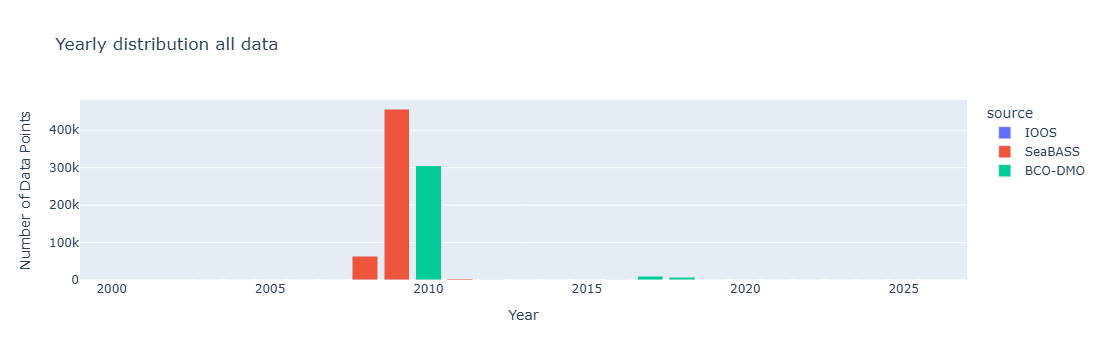

In [22]:
year_test=all_cdom.copy()
year_test['datetime'] = pd.to_datetime(year_test['datetime'])
year_test['year'] = year_test['datetime'].dt.year
grouped = year_test.groupby(['year', 'source']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(
    grouped,
    x='year',
    y='DataPoints',
    color='source',
    title='Yearly distribution all data',
    labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

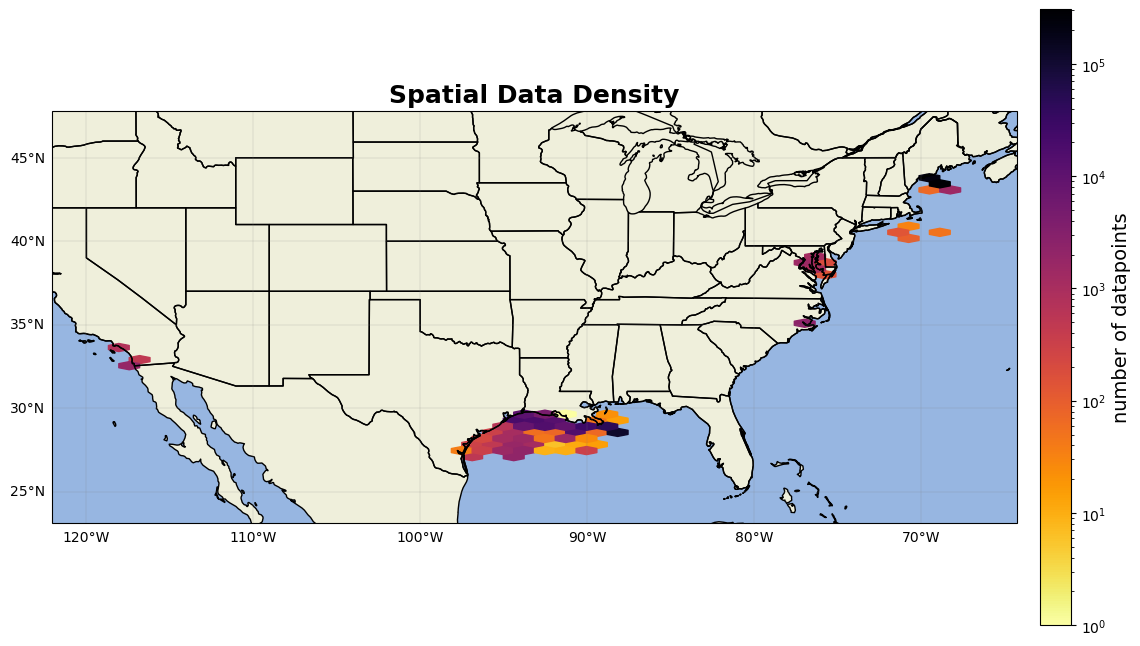

In [23]:
from matplotlib.colors import LogNorm # Important for high-variance data
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)
hb = ax.hexbin(all_cdom.lon, all_cdom.lat, gridsize=40, cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=ax, orientation='vertical', pad=0.02, shrink=0.8)
cb.set_label('number of datapoints', fontsize=14)
gl=ax.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
ax.set_xlim(min(all_cdom.lon)-4,max(all_cdom.lon)+4)
ax.set_ylim(min(all_cdom.lat)-4,max(all_cdom.lat)+4)
ax.set_title('Spatial Data Density', fontsize=18, fontweight='bold')

plt.show()

# concat onto 1 dataframe

In [2]:
#load in all completed dataframes
chl = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\all_chl.xlsx')

In [3]:
rrs = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\all_rrs.xlsx')

In [4]:
rrs = rrs[rrs['wavelength'] <=800].reset_index(drop=True) #reduce to more realistic limit of wavelengths

In [5]:
cdom = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\all_cdom.xlsx')

In [6]:
#first, turn rrs data long format so that there is 1 uinique id for each row / group of wavelengths
def long_to_wide(df):
    """
    Transforms long format to wide format (rrs_###) without averaging duplicates,
    preserving rows even if they have missing metadata (NaNs).
    """
    id_vars = ['source', 'datetime', 'lon', 'lat', 'depth', 'experiment', 'DOI_url','affiliations', 'investigators', 'contact', 'cruise', 'station',
               'ID_code']
    df_temp = df.copy()
    # temporarily fill NaNs with a string so pivot_table doesn't drop them
    df_temp[id_vars] = df_temp[id_vars].fillna('MISSING_DATA')
    
    #group by the full id_vars list to ensure the counter perfectly aligns
    df_temp['temp_counter'] = df_temp.groupby(id_vars + ['wavelength']).cumcount()
    df_wide = df_temp.pivot_table(index=id_vars + ['temp_counter'], columns='wavelength',  values='rrs')
    new_column_names = [f"rrs_{str(col)}" for col in df_wide.columns]
    df_wide.columns = new_column_names
    df_wide = df_wide.reset_index()
    df_wide = df_wide.drop(columns=['temp_counter'])
    return df_wide

rrs_long = long_to_wide(rrs)

In [ ]:
#ok, now to merge the three dataframes together
#for this, i want 2 different final dataframes. one will be only the points that match with the cholorophyll dataset (so for example, if on June 1st 2024
#only cdom was recorded not chl, this isn;t in the dataframe
#the second will be all data together, where if it's incidental it's matching but otherwise it not added 

In [7]:
rrs_long=rrs_long.replace('MISSING_DATA', np.nan)

C:\Users\gianna.milton\AppData\Local\Temp\ipykernel_19588\445826304.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rrs_long=rrs_long.replace('MISSING_DATA', np.nan)


In [8]:
#for appending all datasets together, reduce the rrs and cdom data to just the variables + id 
cdom_reduced = cdom[['cdom', 'ID_code']]
rrs_cols = [col for col in rrs_long.columns if col.startswith('rrs_')]
rrs_reduced = rrs_long[rrs_cols+['ID_code']]

In [9]:
alldata_chl = pd.merge(chl, cdom_reduced, on=['ID_code'], how='outer').reset_index(drop=True)
alldata_chl = alldata_chl.dropna(subset=['chl', 'chl_a'], how='all')
#filtered_df = df_merged[df_merged['chl'].notna() & df_merged['cdom'].notna()] 

In [10]:
alldata_chl = pd.merge(alldata_chl, rrs_reduced, on=['ID_code'], how='outer').reset_index(drop=True)
alldata_chl = alldata_chl.dropna(subset=['chl', 'chl_a'], how='all')

In [11]:
print(str(min(alldata_chl.datetime)) + ' to: ' + str(max(alldata_chl.datetime)))

2000-01-04 14:12:00 to: 2026-01-01 00:00:00


In [12]:
#alldata_chl.to_excel('compiled_chl_variables.xlsx', index = False) #all chlorophyll data with coincidental rrs and cdom data
filename = "compiled_chl_variables.csv.gz"
alldata_chl.to_csv(filename, index=False, compression='gzip')

# format into nccsvs for erddap

In [2]:
print('hi')

hi


In [2]:
chl = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\all_chl.xlsx')


In [3]:
cdom = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\all_cdom.xlsx')

In [4]:
#do an outer match, and any columns without chl or chl_a, remove and make their own dataframe. then rename columns and append 
chl_cdom_pre = pd.merge(chl, cdom, on=['ID_code'], how='outer').reset_index(drop=True)
chl_cdom1 =chl_cdom_pre[['ID_code', 'datetime_x', 'lat_x', 'lon_x', 'chl', 'chl_a','cdom', 'depth_x', 'experiment_x', 'station_x', 'affiliations_x', 'investigators_x',
       'contact', 'cruise_x', 'DOI_url_x', 'HPLC', 'triplicate', 'data_type_flag', 'source_x', 'cast']]
chl_cdom1 = chl_cdom1.dropna(subset=['chl', 'chl_a'], how='all') #seperate the rows with chl and without to later append
chl_cdom1.columns = chl_cdom1.columns.str.replace('_x', '', regex=False)

cdom_2 = chl_cdom_pre[chl_cdom_pre[['chl', 'chl_a']].isna().all(axis=1)]
cdom_2 = cdom_2[['ID_code',  'datetime_y', 'lon_y', 'lat_y','depth_y', 'cdom', 'DOI_url_y', 'affiliations_y', 'investigators_y','experiment_y', 'cruise_y', 
           'station_y', 'source_y']]
cdom_2.columns = cdom_2.columns.str.replace('_y', '', regex=False)

#now, append the dataframe with matching ids and the dataframe without matching ids together
chl_cdom_final = pd.concat([chl_cdom1, cdom_2], ignore_index=True)


In [5]:
print(chl_cdom1.shape)
print(cdom_2.shape)
print(chl_cdom_final.shape)

(708412, 20)
(850800, 13)
(1559212, 20)


In [6]:
#RRS to chl_cdom
rrs = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\all_rrs.xlsx')
rrs = rrs[rrs['wavelength'] <=800].reset_index(drop=True) #reduce to more realistic limit of wavelengths
#first, turn rrs data long format so that there is 1 uinique id for each row / group of wavelengths
def long_to_wide(df):
    """
    Transforms long format to wide format (rrs_###) without averaging duplicates,
    preserving rows even if they have missing metadata (NaNs).
    """
    id_vars = ['source', 'datetime', 'lon', 'lat', 'depth', 'experiment', 'DOI_url','affiliations', 'investigators', 'contact', 'cruise', 'station',
               'ID_code']
    df_temp = df.copy()
    # temporarily fill NaNs with a string so pivot_table doesn't drop them
    df_temp[id_vars] = df_temp[id_vars].fillna('MISSING_DATA')
    
    #group by the full id_vars list to ensure the counter perfectly aligns
    df_temp['temp_counter'] = df_temp.groupby(id_vars + ['wavelength']).cumcount()
    df_wide = df_temp.pivot_table(index=id_vars + ['temp_counter'], columns='wavelength',  values='rrs')
    new_column_names = [f"rrs_{str(col)}" for col in df_wide.columns]
    df_wide.columns = new_column_names
    df_wide = df_wide.reset_index()
    df_wide = df_wide.drop(columns=['temp_counter'])
    return df_wide

rrs_long = long_to_wide(rrs)
rrs_long=rrs_long.replace('MISSING_DATA', np.nan)

In [7]:
len(rrs_long)

51085

In [8]:
rrs_columns = [col for col in rrs_long.columns if str(col).startswith('rrs_')] #grab all rrs columns

chl_cdom_rrs_pre = pd.merge(chl_cdom_final, rrs_long, on=['ID_code'], how='outer').reset_index(drop=True)
chl_cdom_rrs1 =chl_cdom_rrs_pre[['ID_code', 'datetime_x', 'lat_x', 'lon_x', 'chl', 'chl_a', 'cdom','depth_x', 'experiment_x', 'station_x', 
                                 'affiliations_x','investigators_x', 'contact_x', 'cruise_x', 'DOI_url_x', 'HPLC','triplicate',
                                 'data_type_flag', 'source_x', 'cast']+rrs_columns]
chl_cdom_rrs1.dropna(axis=1, how='all', inplace=True) #remove any empty columns
chl_cdom_rrs1 = chl_cdom_rrs1.dropna(subset=['chl', 'chl_a', 'cdom'], how='all') #remove columns that don't have original values
chl_cdom_rrs1.columns = chl_cdom_rrs1.columns.str.replace('_x', '', regex=False)

#get dataframe of only rrs values without coincidental values
rrs_2 = chl_cdom_rrs_pre[chl_cdom_rrs_pre[['chl', 'chl_a', 'cdom']].isna().all(axis=1)]
rrs_2=rrs_2[['ID_code', 'source_y','datetime_y', 'lon_y', 'lat_y', 'depth_y', 'experiment_y', 'DOI_url_y','affiliations_y', 'investigators_y',
             'contact_y', 'cruise_y','station_y']+rrs_columns]
rrs_2.columns = rrs_2.columns.str.replace('_y', '', regex=False)

chl_cdom_rrs_final = pd.concat([chl_cdom_rrs1, rrs_2], ignore_index=True)

C:\Users\gianna.milton\AppData\Local\Temp\ipykernel_7156\1453218713.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  chl_cdom_rrs1.dropna(axis=1, how='all', inplace=True) #remove any empty columns


In [9]:
print(chl_cdom_rrs1.shape)
print(rrs_2.shape)
print(chl_cdom_rrs_final.shape)
#print(chl_cdom_rrs_final.columns[:40])

(1559212, 498)
(50239, 491)
(1609451, 498)


In [10]:
chl_cdom_rrs_final['datetime'] = chl_cdom_rrs_final['datetime'].apply(pd.to_datetime)

In [11]:
chl_cdom_rrs_final['datetime'] = pd.to_datetime(chl_cdom_rrs_final['datetime'], format="%Y/%m/%d %H:%M:%S", errors='coerce')

# 2. To display specifically as "YYYY-MM-DD HH:mm:ss" (as a string)
#chl_cdom_rrs_final['datetime'] = chl_cdom_rrs_final['datetime'].dt.strftime('%Y-%m-%d %H:%M:%S')
#chl_cdom_rrs_final['datetime'] = pd.to_datetime(chl_cdom_rrs_final['datetime'])


In [13]:
print(chl_cdom_rrs_final.datetime.min())
print(chl_cdom_rrs_final.depth.max())

2000-01-04 14:12:00
150.0


In [ ]:
#things to fix here: 
                                                                                                        #update depth
                                                                                                        #change/update summary
                                                                                                        #change/ update file names
                                                                                                        #add github link 
                                                                                                        #update east ad west in to be more correct 
                                                                                                        #fix date issues (check 2000-08-01 has hh,mm,ss
                                                                                                        #add history to global with each source (maybe a paragraph), for a general history of how i download, manipulate, then save 
                                                                                                        # go thru the erdab_metadata file and double check all global stuff and variable stuff is here 
                                                                                                        #go through emolt file and add stuff that;s missing

In [14]:
#group by the year and loop through each group
for year, group in chl_cdom_rrs_final.groupby(chl_cdom_rrs_final['datetime'].dt.year):
#now that we have a dataframe, put into nccsv file 
    group=group.reset_index(drop=True)
    metadata = [
        #Global
        ['*GLOBAL*', 'Conventions', 'COARDS, CF-1.6, ACDD-1.3, NCCSV-1.2'],
        ['*GLOBAL*', 'acknowledgement', 'The data are sponsored by NOAA and may be freely distributed.'],
        ['*GLOBAL*', 'institution', 'DOC | NOAA | National Marine Fisheries Service | Northeast Fisheries Science Center '],
        ['*GLOBAL*', 'naming_authority', 'gov.noaa.nefsc'],
        ['*GLOBAL*', 'license', 'The data may be used and redistributed for free but is not intended for legal use, since it may contain inaccuracies.  Neither the data, contributor, NEFSC, NOAA, nor the United States Government, nor any of their employees or contractors, makes any warranty, expressed or implied, including warranties of marketability and fitness for a particular purpose, or assumes any legal liability for the accuracy, completeness, or usefulness of this information.'],
        ['*GLOBAL*', 'creator_type', 'group'],
        ['*GLOBAL*', 'creator_name','Ecosystem Dynamics and Assessment Branch'],
        ['*GLOBAL*', 'creator_url','https://www.fisheries.noaa.gov/new-england-mid-atlantic/ecosystems/northeast-ecosystem-dynamics-and-assessment-our-research'],
        ['*GLOBAL*', 'creator_email','edab.data@noaa.gov'],
        ['*GLOBAL*', 'program_name','Ecosystem Dynamics and Assessment Branch'],
        ['*GLOBAL*', 'publisher_type','institution'],
        ['*GLOBAL*', 'publisher_name','DOC | NOAA | National Marine Fisheries Service | Northeast Fisheries Science Center'],
        ['*GLOBAL*', 'publisher_url','https://www.fisheries.noaa.gov/about/northeast-fisheries-science-center'],
        ['*GLOBAL*', 'publisher_email','nefsc.erddap@noaa.gov'],
        
        ['*GLOBAL*', 'contact_name','Kimberly Hyde'],
        ['*GLOBAL*', 'contact_email','kimberly.hyde@noaa.gov '],
        ['*GLOBAL*', 'creator_name','Gianna Milton'],
        ['*GLOBAL*', 'contributor_name','Gianna Milton'],
        ['*GLOBAL*', 'contributor_email','gianna.milton@noaa.gov'],
        ['*GLOBAL*', 'contributor_type','person'],
        ['*GLOBAL*', 'contributor_role','Provided the python code, QA/QC, analysis, and aggregation of product'],

        ['*GLOBAL*', 'history','Chlorophyll, cdom, and Rrs data was gathered from SeaBASS, IOOS, WOD, CIOOS, BCO-DMO, CalCOFI, SEAMAP, HOTS, Pan-Arctic, and GLORIA datasets. All data was subset to 2000-2025, North American coastal waters, and the top 150 meters. Chlorophyll measurments also had methodological flags added for end users to determine methods used. Metadata was attached to each sample to ensure FAIR metadata standards.'],
        ['*GLOBAL*', 'project_name','Validation of Coastal Remote Sensing Products for the Climate, Ecosystems, and Fisheries Initiative'],
        ['*GLOBAL*', 'project_url','https://github.com/NEFSC/READ-EDAB-GMilton-CoastalChlorophyll'],
        ['*GLOBAL*', 'infoUrl','https://nefsc.github.io/READ-EDAB-GMilton-CoastalChlorophyll/'],
        ['*GLOBAL*', 'dataUrl','10.5281/zenodo.20140178'],

        ['*GLOBAL*', 'date_created', '2026-06-05'], 
        ['*GLOBAL*', 'time_coverage_start', str(group['datetime'].min())], 
        ['*GLOBAL*', 'time_coverage_end', str(group['datetime'].max())], 
        
        ['*GLOBAL*', 'geospatial_lat_min', '-0.590533333'],
        ['*GLOBAL*', 'geospatial_lat_max', '78.303167'],  
        ['*GLOBAL*', 'geospatial_lat_units', 'decimal degrees north'], 
        ['*GLOBAL*', 'geospatial_lon_min', '149.001'],  #furthest west
        ['*GLOBAL*', 'geospatial_lon_max', '-46.8893'], #furthest east
        ['*GLOBAL*', 'geospatial_lon_units', 'decimal degrees east'],
        ['*GLOBAL*', 'geospatial_vertical_max', '150'],
        ['*GLOBAL*', 'geospatial_vertical_min', '-8.5'],
        ['*GLOBAL*', 'geospatial_vertical_positive', 'down'],
        ['*GLOBAL*', 'geospatial_vertical_units', 'meters'],
        ['*GLOBAL*', 'cdm_data_type', 'point'],
        #do i need processing level and geospatial_lat_resolution and geospatial_lon_resolution
        #time_coverage_duration, time_coverage_resolution
        
        ['*GLOBAL*', 'summary', 'A North American dataset of quality controlled chlorophyll, cdom, and Rrs measurements and associated metadata from 11 public datasets for coastal algorithm development'],
        ['*GLOBAL*', 'title', 'Coastal North America In Situ Chlorophyll and Optical Dataset'],
        ['*GLOBAL*', 'keywords', 'Earth Science > Oceans > Ocean Chemistry > Pigments > Chlorophyll'],
        ['*GLOBAL*', 'keywords', 'Concentration of chromophoric dissolved organic matter'], ### NO STANDARD CDOM ?????
        ['*GLOBAL*', 'keywords', 'Platforms > Space-based Platforms > Earth Observation Satellites, Instruments > Earth Remote Sensing Instruments > Passive Remote Sensing > Photon/Optical Detectors > Passive Remote Sensing, Instruments > Earth Remote Sensing Instruments > Passive Remote Sensing > Photon/Optical Detectors > Passive Remote Sensing'],
        ['*GLOBAL*', 'keyword_vocabulary', 'GCMD Science Keywords'], 
        ['*GLOBAL*', 'standard_name_vocabulary', 'CF Standard Name Table v92'], 

        # ID_code
        ['ID_code', '*DATA_TYPE*', 'String'],
        ['ID_code', 'long_name', 'Unique ID code'],
        
        # datetime
        ['datetime', '*DATA_TYPE*', 'String'],
        ['datetime', 'long_name', 'Datetime'],
        ['datetime', 'units', 'YYYY-MM-dd HH:mm:ss'],   
        ['datetime', '_FillValue', 'NaNT'],  
        ['datetime', 'standard_name', 'time'],   
        
        #lat
        ['lat', '*DATA_TYPE*', 'float'],
        ['lat', 'long_name','Latitude'],
        ['lat', 'units', 'degrees_north'],  
        ['lat', '_FillValue', 'NaN'],  
        ['lat', 'standard_name', 'Latitude'],  
        #lon
        ['lon', '*DATA_TYPE*', 'float'],
        ['lon', 'long_name','Longitude'],
        ['lon', 'units', 'degrees_east'],      
        ['lon', '_FillValue', 'NaN'],  
        ['lon', 'standard_name', 'longitude'], 
        #chl
        ['chl', '*DATA_TYPE*', 'float'],
        ['chl', 'long_name', 'Chlorophyll Concentration'],
        ['chl', 'standard_name', 'mass_concentration_of_chlorophyll_in_sea_water'],
        ['chl', 'units', 'mg m-3'],
        ['chl', '_FillValue', 'NaN'],  
        ['chl', 'valid_minimum', '0.0001'],
        ['chl', 'valid_maximum', '100'],  
        #chl_a
        ['chl_a', '*DATA_TYPE*', 'float'],
        ['chl_a', 'long_name', 'Chlorophyll_a Concentration'],
        ['chl_a', 'standard_name', 'mass_concentration_of_chlorophyll_a_in_sea_water'],
        ['chl_a', 'units', 'mg m-3'],
        ['chl_a', '_FillValue', 'NaN'],  
        ['chl_a', 'valid_minimum', '0.0001'],
        ['chl_a', 'valid_maximum', '100'], 
        #cdom
        ['cdom', '*DATA_TYPE*', 'float'],
        ['cdom', 'long_name', 'Concentration of chromophoric dissolved organic matter'],
        ['cdom', 'standard_name', 'colored_dissolved_organic_matter'],
        ['cdom', 'units', 'mg m-3'],
        ['cdom', '_FillValue', 'NaN'],  
        ['cdom', 'valid_minimum', '0'],
        ['cdom', 'valid_maximum', '618'], 
    
        #depth
        ['depth', '*DATA_TYPE*', 'float'],
        ['depth', 'long_name', 'Depth of measurment'],
        ['depth', 'units', 'm'],
        ['depth', 'direction', 'down'], 
        ['depth', 'standard_name', 'depth'],
        ['depth', '_FillValue', 'NaN'],  
    
           # experiment
        ['experiment', '*DATA_TYPE*', 'String'],
        ['experiment', 'long_name', 'Name of experiment or program collecting measurment'],
        ['experiment', '_FillValue', 'NaN'],  
        
            #station
        ['station', '*DATA_TYPE*', 'String'],
        ['station', 'long_name', 'station of measurment'],
        ['station', '_FillValue', 'NaN'],  
    
           # affiliations
        ['affiliations', '*DATA_TYPE*', 'String'],
        ['affiliations', 'long_name', 'affiliation or university responsible for measurment'],
        ['affiliations', '_FillValue', 'NaN'],  
            
            # investigator
        ['investigators', '*DATA_TYPE*', 'String'],
        ['investigators', 'long_name', 'PI responsible for measurment collection'],
        ['investigators', '_FillValue', 'NaN'],  
            
            # contact
        ['contact', '*DATA_TYPE*', 'String'],
        ['contact', 'long_name', 'contact information of investigators'],
        ['contact', '_FillValue', 'NaN'],  
    
                #cruise
        ['cruise', '*DATA_TYPE*', 'String'],
        ['cruise', 'long_name', 'cruise name of measurment'],
        ['cruise', '_FillValue', 'NaN'],  
    
                #DOI_url
        ['DOI_url', '*DATA_TYPE*', 'String'],
        ['DOI_url', 'long_name', 'DOI or website link to measurment repository'],
        ['DOI_url', '_FillValue', 'NaN'],  
    
         
            # HPLC
        ['HPLC', '*DATA_TYPE*', 'int'],
        ['HPLC', 'long_name', 'HPLC flag indicating HPLC methods'],
        ['HPLC', 'standard_name', 'HPLC flag'],
        ['HPLC', 'units', 'flag (0= HPLC used, 1=no HPLC used, 2 = most likely HPLC used)'],
        ['HPLC', '_FillValue', 'NaN'],  
    
            # triplicate
        ['triplicate', '*DATA_TYPE*', 'int'],
        ['triplicate', 'long_name', 'triplicate flag indicating measurment recorded in triplicates'],
        ['triplicate', 'standard_name', 'triplicate flag'],
        ['triplicate', 'units', 'flag (0= triplicate used, 1=no triplicate used'],
        ['triplicate', '_FillValue', 'NaN'],  
    
                    #data_type_flag
        ['data_type_flag', '*DATA_TYPE*', 'int'],
        ['data_type_flag', 'long_name', 'flag indicating extracted or in vivo methods used '],
        ['data_type_flag', 'standard_name', 'data type flag'],
        ['data_type_flag', 'units', 'flag (0= extracted, 1=in-vivo, 2 = uncertain'],
        ['data_type_flag', '_FillValue', 'NaN'],  
    
                    #source
        ['source', '*DATA_TYPE*', 'String'],
        ['source', 'long_name', 'repository or program/source that measurment is stored'],
        ['source', '_FillValue', 'NaN'],  
    
                    #cast
        ['cast', '*DATA_TYPE*', 'String'],
        ['cast', 'long_name', 'cast number of data measurment'],
        ['cast', '_FillValue', 'NaN'],  
    
    ]
    rrs_columns = [col for col in group.columns if str(col).startswith('rrs_')] #grab all rrs columns

    for col in rrs_columns:
        wavelength = col.split('_')[1] 
        rrs_metadata_block = [[col, '*DATA_TYPE*', 'float'],
            [col, 'long_name', f'Sea surface reflectance defined as the ratio of water-leaving radiance to surface irradiance at wavelength: {wavelength} nm'],
            [col, 'standard_name', 'surface_ratio_of_upwelling_radiance_emerging_from_sea_water_to_downwelling_radiative_flux_in_air'],
            [col, 'valid_minimum', '0'],
            [col, 'valid_maximum', '0.1'],
            [col, 'units', 'Steradian -1'],
            [col, '_FillValue', 'NaN']]
    
        metadata.extend(rrs_metadata_block)#extend adds these new rows to the end of our main 'metadata' list
        
    output_folder = r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\erddap_projects'

    file_name = f"coastalCHL_CDOM_RRS_insitu_{year}.csv"
    file_path = os.path.join(output_folder, file_name)
    with open(file_path, 'w', newline='') as file: #this might have to be file_name
        writer = csv.writer(file)
        
        # Write each metadata row
        for row in metadata:
            writer.writerow(row)
            
        # Write the mandatory end-of-metadata flag
        writer.writerow(['*END_METADATA*'])
    group.to_csv(file_path, mode='a', index=False, date_format='%Y-%m-%d %H:%M:%S')
    print(f"Exported: {file_path}")


Exported: C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\erddap_projects\coastalCHL_CDOM_RRS_insitu_2000.csv
Exported: C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\erddap_projects\coastalCHL_CDOM_RRS_insitu_2001.csv
Exported: C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\erddap_projects\coastalCHL_CDOM_RRS_insitu_2002.csv
Exported: C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\erddap_projects\coastalCHL_CDOM_RRS_insitu_2003.csv
Exported: C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\erddap_projects\coastalCHL_CDOM_RRS_insitu_2004.csv
Exported: C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\erddap_projects\coastalCHL_CDOM_RRS_insitu_2005.csv
Exported: C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\erddap_projects\coastalCHL_CDOM_RRS_insitu_2006.csv
Exported: C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\erddap_projects\coastalCHL_CDOM_RRS_insitu_2007.csv
Exported: C:\Users\gianna.milton\Documen

In [14]:
#now that we have a dataframe, put into nccsv file 
metadata = [
    #Global
    ['*GLOBAL*', 'Conventions', 'COARDS, CF-1.6, ACDD-1.3, NCCSV-1.2'],
    ['*GLOBAL*', 'acknowledgement', 'The data are sponsored by NOAA and may be freely distributed.'],
    ['*GLOBAL*', 'institution', 'DOC | NOAA | National Marine Fisheries Service | Northeast Fisheries Science Center '],
    ['*GLOBAL*', 'naming_authority', 'gov.noaa.nefsc'],
    ['*GLOBAL*', 'license', 'The data may be used and redistributed for free but is not intended for legal use, since it may contain inaccuracies.  Neither the data, contributor, NEFSC, NOAA, nor the United States Government, nor any of their employees or contractors, makes any warranty, expressed or implied, including warranties of marketability and fitness for a particular purpose, or assumes any legal liability for the accuracy, completeness, or usefulness of this information.'],
    ['*GLOBAL*', 'creator_type', 'group'],
    ['*GLOBAL*', 'creator_name','Ecosystem Dynamics and Assessment Branch'],
    ['*GLOBAL*', 'creator_url','https://www.fisheries.noaa.gov/new-england-mid-atlantic/ecosystems/northeast-ecosystem-dynamics-and-assessment-our-research'],
    ['*GLOBAL*', 'creator_email','edab.data@noaa.gov'],
    ['*GLOBAL*', 'program_name','Ecosystem Dynamics and Assessment Branch'],
    ['*GLOBAL*', 'publisher_type','institution'],
    ['*GLOBAL*', 'publisher_name','DOC | NOAA | National Marine Fisheries Service | Northeast Fisheries Science Center'],
    ['*GLOBAL*', 'publisher_url','https://www.fisheries.noaa.gov/about/northeast-fisheries-science-center'],
    ['*GLOBAL*', 'publisher_email','nefsc.erddap@noaa.gov'],
    ['*GLOBAL*', 'contributor_name','Gianna Milton'],
    ['*GLOBAL*', 'contributor_type','person'],
    ['*GLOBAL*', 'project_name','Coastal chlorophyll dataset in North America'],
    ['*GLOBAL*', 'project_url','https://github.com/GMilton2/coastal-chlorophyll'],
 #FIX THESE
    ['*GLOBAL*', 'date_created', '2026-05-21'], 
    ['*GLOBAL*', 'time_coverage_start', '2000-01-04 14:12:00'], 
    ['*GLOBAL*', 'time_coverage_end', '2026-01-01 00:00:00'],      
    ['*GLOBAL*', 'geospatial_lat_min', '-0.590533333'],
    ['*GLOBAL*', 'geospatial_lat_max', '78.303167'],  
    ['*GLOBAL*', 'geospatial_lat_units', 'decimal degrees north'], 
    ['*GLOBAL*', 'geospatial_lon_min', '-179.905'], 
    ['*GLOBAL*', 'geospatial_lon_max', '149.001'],
    ['*GLOBAL*', 'geospatial_lon_units', 'decimal degrees east'],
    ['*GLOBAL*', 'geospatial_vertical_max', '509'],
    ['*GLOBAL*', 'geospatial_vertical_min', '-8.5'],
    ['*GLOBAL*', 'geospatial_vertical_positive', 'down'],
    ['*GLOBAL*', 'geospatial_vertical_units', 'meters'],
    ['*GLOBAL*', 'cdm_data_type', 'point'],
    
    ['*GLOBAL*', 'summary', 'All chlorophyll, chlorophyll_a, chromophoric dissolved organic matter, and Remote sensing reflectance measurements for the coastal chlorophyll dataset'],
    ['*GLOBAL*', 'title', 'Coastal chlorophyll dataset in North America'],
    ['*GLOBAL*', 'keywords', 'Earth Science > Oceans > Ocean Chemistry > Pigments > Chlorophyll'],
    ['*GLOBAL*', 'keywords', 'Concentration of chromophoric dissolved organic matter'], ### NO STANDARD CDOM ?????
    ['*GLOBAL*', 'keywords', 'Platforms > Space-based Platforms > Earth Observation Satellites, Instruments > Earth Remote Sensing Instruments > Passive Remote Sensing > Photon/Optical Detectors > Passive Remote Sensing, Instruments > Earth Remote Sensing Instruments > Passive Remote Sensing > Photon/Optical Detectors > Passive Remote Sensing'],


    # ID_code
    ['ID_code', '*DATA_TYPE*', 'String'],
    ['ID_code', 'long_name', 'Unique ID code'],
    
    # datetime
    ['datetime', '*DATA_TYPE*', 'String'],
    ['datetime', 'long_name', 'Datetime'],
    ['datetime', 'units', 'YYYY-MM-dd HH:mm:ss'],   
    ['datetime', '_FillValue', 'NaNT'],  
    ['datetime', 'standard_name', 'time'],   
    
    #lat
    ['lat', '*DATA_TYPE*', 'float'],
    ['lat', 'long_name','Latitude'],
    ['lat', 'units', 'degrees_north'],  
    ['lat', '_FillValue', 'NaN'],  
    ['lat', 'standard_name', 'Latitude'],  
    #lon
    ['lon', '*DATA_TYPE*', 'float'],
    ['lon', 'long_name','Longitude'],
    ['lon', 'units', 'degrees_east'],      
    ['lon', '_FillValue', 'NaN'],  
    ['lon', 'standard_name', 'longitude'], 
    #chl
    ['chl', '*DATA_TYPE*', 'float'],
    ['chl', 'long_name', 'Chlorophyll Concentration'],
    ['chl', 'standard_name', 'mass_concentration_of_chlorophyll_in_sea_water'],
    ['chl', 'units', 'mg m-3'],
    ['chl', '_FillValue', 'NaN'],  
    ['chl', 'valid_minimum', '0.0001'],
    ['chl', 'valid_maximum', '100'],  
    #chl_a
    ['chl_a', '*DATA_TYPE*', 'float'],
    ['chl_a', 'long_name', 'Chlorophyll_a Concentration'],
    ['chl_a', 'standard_name', 'mass_concentration_of_chlorophyll_a_in_sea_water'],
    ['chl_a', 'units', 'mg m-3'],
    ['chl_a', '_FillValue', 'NaN'],  
    ['chl_a', 'valid_minimum', '0.0001'],
    ['chl_a', 'valid_maximum', '100'], 
    #cdom
    ['cdom', '*DATA_TYPE*', 'float'],
    ['cdom', 'long_name', 'Concentration of chromophoric dissolved organic matter'],
    ['cdom', 'standard_name', 'colored_dissolved_organic_matter'],
    ['cdom', 'units', 'mg m-3'],
    ['cdom', '_FillValue', 'NaN'],  
    ['cdom', 'valid_minimum', '0'],
    ['cdom', 'valid_maximum', '618'], 

    #depth
    ['depth', '*DATA_TYPE*', 'float'],
    ['depth', 'long_name', 'Depth of measurment'],
    ['depth', 'units', 'm'],
    ['depth', 'direction', 'down'], 
    ['depth', 'standard_name', 'depth'],
    ['depth', '_FillValue', 'NaN'],  

       # experiment
    ['experiment', '*DATA_TYPE*', 'String'],
    ['experiment', 'long_name', 'Name of experiment or program collecting measurment'],
    ['experiment', '_FillValue', 'NaN'],  
    
        #station
    ['station', '*DATA_TYPE*', 'String'],
    ['station', 'long_name', 'station of measurment'],
    ['station', '_FillValue', 'NaN'],  

       # affiliations
    ['affiliations', '*DATA_TYPE*', 'String'],
    ['affiliations', 'long_name', 'affiliation or university responsible for measurment'],
    ['affiliations', '_FillValue', 'NaN'],  
        
        # investigator
    ['investigators', '*DATA_TYPE*', 'String'],
    ['investigators', 'long_name', 'PI responsible for measurment collection'],
    ['investigators', '_FillValue', 'NaN'],  
        
        # contact
    ['contact', '*DATA_TYPE*', 'String'],
    ['contact', 'long_name', 'contact information of investigators'],
    ['contact', '_FillValue', 'NaN'],  

            #cruise
    ['cruise', '*DATA_TYPE*', 'String'],
    ['cruise', 'long_name', 'cruise name of measurment'],
    ['cruise', '_FillValue', 'NaN'],  

            #DOI_url
    ['DOI_url', '*DATA_TYPE*', 'String'],
    ['DOI_url', 'long_name', 'DOI or website link to measurment repository'],
    ['DOI_url', '_FillValue', 'NaN'],  

     
        # HPLC
    ['HPLC', '*DATA_TYPE*', 'int'],
    ['HPLC', 'long_name', 'HPLC flag indicating HPLC methods'],
    ['HPLC', 'standard_name', 'HPLC flag'],
    ['HPLC', 'units', 'flag (0= HPLC used, 1=no HPLC used, 2 = most likely HPLC used)'],
    ['HPLC', '_FillValue', 'NaN'],  

        # triplicate
    ['triplicate', '*DATA_TYPE*', 'int'],
    ['triplicate', 'long_name', 'triplicate flag indicating measurment recorded in triplicates'],
    ['triplicate', 'standard_name', 'triplicate flag'],
    ['triplicate', 'units', 'flag (0= triplicate used, 1=no triplicate used'],
    ['triplicate', '_FillValue', 'NaN'],  

                #data_type_flag
    ['data_type_flag', '*DATA_TYPE*', 'int'],
    ['data_type_flag', 'long_name', 'flag indicating extracted or in vivo methods used '],
    ['data_type_flag', 'standard_name', 'data type flag'],
    ['data_type_flag', 'units', 'flag (0= extracted, 1=in-vivo, 2 = uncertain'],
    ['data_type_flag', '_FillValue', 'NaN'],  

                #source
    ['source', '*DATA_TYPE*', 'String'],
    ['source', 'long_name', 'repository or program/source that measurment is stored'],
    ['source', '_FillValue', 'NaN'],  

                #cast
    ['cast', '*DATA_TYPE*', 'String'],
    ['cast', 'long_name', 'cast number of data measurment'],
    ['cast', '_FillValue', 'NaN'],  

]

In [15]:
rrs_columns = [col for col in chl_cdom_rrs_final.columns if str(col).startswith('rrs_')] #grab all rrs columns

for col in rrs_columns:
    wavelength = col.split('_')[1] 
    rrs_metadata_block = [
        [col, '*DATA_TYPE*', 'float'],
        [col, 'long_name', f'Sea surface reflectance defined as the ratio of water-leaving radiance to surface irradiance at wavelength: {wavelength} nm'],
        [col, 'standard_name', 'surface_ratio_of_upwelling_radiance_emerging_from_sea_water_to_downwelling_radiative_flux_in_air'],
        [col, 'valid_minimum', '0'],
        [col, 'valid_maximum', '0.1'],
        [col, 'units', 'Steradian -1'],
        [col, '_FillValue', 'NaN'], 
    ]
    
    # Extend adds these new rows to the end of our main 'metadata' list
    metadata.extend(rrs_metadata_block)

In [16]:
import csv
output_filename = 'CoastalCHL_dataset.csv'

# Step A: Open the file in write mode to create the metadata header
with open(output_filename, 'w', newline='') as file:
    writer = csv.writer(file)
    
    # Write each metadata row
    for row in metadata:
        writer.writerow(row)
        
    # Write the mandatory end-of-metadata flag
    writer.writerow(['*END_METADATA*'])
    
# Step B: Append the DataFrame to the exact same file
# mode='a' stands for "append", so it won't overwrite our metadata
chl_cdom_rrs_final.to_csv(output_filename, mode='a', index=False)

## Turn dataset into 25 files by year

In [2]:
chl = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\all_chl.xlsx')

In [10]:
print(chl.chl_a.min())
print(chl.chl_a.max())

0.0
105.0152923


In [11]:
metadata = [
    #Global
    ['*GLOBAL*', 'Conventions', 'COARDS, CF-1.6, ACDD-1.3, NCCSV-1.2'],
    ['*GLOBAL*', 'acknowledgement', 'The data are sponsored by NOAA and may be freely distributed.'],
    ['*GLOBAL*', 'institution', 'DOC | NOAA | National Marine Fisheries Service | Northeast Fisheries Science Center '],
    ['*GLOBAL*', 'naming_authority', 'gov.noaa.nefsc'],
    ['*GLOBAL*', 'license', 'The data may be used and redistributed for free but is not intended for legal use, since it may contain inaccuracies.  Neither the data, contributor, NEFSC, NOAA, nor the United States Government, nor any of their employees or contractors, makes any warranty, expressed or implied, including warranties of marketability and fitness for a particular purpose, or assumes any legal liability for the accuracy, completeness, or usefulness of this information.'],
    ['*GLOBAL*', 'creator_type', 'group'],
    ['*GLOBAL*', 'creator_name','Ecosystem Dynamics and Assessment Branch'],
    ['*GLOBAL*', 'creator_url','https://www.fisheries.noaa.gov/new-england-mid-atlantic/ecosystems/northeast-ecosystem-dynamics-and-assessment-our-research'],
    ['*GLOBAL*', 'creator_email','edab.data@noaa.gov'],
    ['*GLOBAL*', 'program_name','Ecosystem Dynamics and Assessment Branch'],
    ['*GLOBAL*', 'publisher_type','institution'],
    ['*GLOBAL*', 'publisher_name','DOC | NOAA | National Marine Fisheries Service | Northeast Fisheries Science Center'],
    ['*GLOBAL*', 'publisher_url','https://www.fisheries.noaa.gov/about/northeast-fisheries-science-center'],
    ['*GLOBAL*', 'publisher_email','nefsc.erddap@noaa.gov'],
    ['*GLOBAL*', 'contributor_name','Gianna Milton'],
    ['*GLOBAL*', 'contributor_type','person'],
    ['*GLOBAL*', 'project_name','Coastal chlorophyll dataset in North America'],
    ['*GLOBAL*', 'project_url','https://github.com/GMilton2/coastal-chlorophyll'],

    ['*GLOBAL*', 'date_created', '2026-05-11'], 
    ['*GLOBAL*', 'time_coverage_start', '2000-01-04 14:12:00'], 
    ['*GLOBAL*', 'time_coverage_end', '2026-01-01 00:00:00'],      
    ['*GLOBAL*', 'geospatial_lat_min', '-0.590533333'],
    ['*GLOBAL*', 'geospatial_lat_max', '78.303167'],  
    ['*GLOBAL*', 'geospatial_lat_units', 'decimal degrees north'], 
    ['*GLOBAL*', 'geospatial_lon_min', '-179.905'], 
    ['*GLOBAL*', 'geospatial_lon_max', '149.001'],
    ['*GLOBAL*', 'geospatial_lon_units', 'decimal degrees east'],
    ['*GLOBAL*', 'geospatial_vertical_max', '509'],
    ['*GLOBAL*', 'geospatial_vertical_min', '-8.9'],
    ['*GLOBAL*', 'geospatial_vertical_positive', 'down'],
    ['*GLOBAL*', 'geospatial_vertical_units', 'meters'],
    ['*GLOBAL*', 'cdm_data_type', 'point'],
    
    ['*GLOBAL*', 'summary', 'All chlorophyll and chlorophyll_a samples for coastal chlorophyll dataset'],
    ['*GLOBAL*', 'title', 'Coastal chlorophyll dataset in North America'],
    ['*GLOBAL*', 'keywords', 'Earth Science > Oceans > Ocean Chemistry > Pigments > Chlorophyll'],

    # ID_CODE
    ['ID_CODE', '*DATA_TYPE*', 'String'],
    ['ID_CODE', 'long_name', 'Unique ID code'],
    
    # datetime
    ['datetime', '*DATA_TYPE*', 'String'],
    ['datetime', 'long_name', 'Datetime'],
    ['datetime', 'units', 'YYYY-MM-dd HH:mm:ss'],   
    ['datetime', '_FillValue', 'NaNT'],  
    ['datetime', 'standard_name', 'time'],   
    
    #lat
    ['lat', '*DATA_TYPE*', 'float'],
    ['lat', 'long_name','Latitude'],
    ['lat', 'units', 'degrees_north'],  
    ['lat', '_FillValue', 'NaN'],  
    ['lat', 'standard_name', 'Latitude'],  
    #lon
    ['lon', '*DATA_TYPE*', 'float'],
    ['lon', 'long_name','Longitude'],
    ['lon', 'units', 'degrees_east'],      
    ['lon', '_FillValue', 'NaN'],  
    ['lon', 'standard_name', 'longitude'], 
    #chl
    ['chl', '*DATA_TYPE*', 'float'],
    ['chl', 'long_name', 'Chlorophyll Concentration'],
    ['chl', 'standard_name', 'mass_concentration_of_chlorophyll_in_sea_water'],
    ['chl', 'units', 'mg m-3'],
    ['chl', '_FillValue', 'NaN'],  
    ['chl', 'valid_minimum', '0.0001'],
    ['chl', 'valid_maximum', '100'],  
    #chl_a
    ['chl_a', '*DATA_TYPE*', 'float'],
    ['chl_a', 'long_name', 'Chlorophyll_a Concentration'],
    ['chl_a', 'standard_name', 'mass_concentration_of_chlorophyll_a_in_sea_water'],
    ['chl_a', 'units', 'mg m-3'],
    ['chl_a', '_FillValue', 'NaN'],  
    ['chl_a', 'valid_minimum', '0.0001'],
    ['chl_a', 'valid_maximum', '100'], 

    #depth
    ['depth', '*DATA_TYPE*', 'float'],
    ['depth', 'long_name', 'Depth of Sample '],
    ['depth', 'units', 'm'],
    ['depth', 'direction', 'down'], 
    ['depth', 'standard_name', 'depth'],
    ['depth', '_FillValue', 'NaN'],  

       # experiment
    ['experiment', '*DATA_TYPE*', 'String'],
    ['experiment', 'long_name', 'Name of experiment or program collecting sample'],
    ['experiment', '_FillValue', 'NaN'],  
    
        #station
    ['station', '*DATA_TYPE*', 'String'],
    ['station', 'long_name', 'station of sample'],
    ['station', '_FillValue', 'NaN'],  

       # affiliations
    ['affiliations', '*DATA_TYPE*', 'String'],
    ['affiliations', 'long_name', 'affiliation or university responsible for sample'],
    ['affiliations', '_FillValue', 'NaN'],  
        
        # investigator
    ['investigators', '*DATA_TYPE*', 'String'],
    ['investigators', 'long_name', 'PI responsible for sample collection'],
    ['investigators', '_FillValue', 'NaN'],  
        
        # contact
    ['contact', '*DATA_TYPE*', 'String'],
    ['contact', 'long_name', 'contact information of investigators'],
    ['contact', '_FillValue', 'NaN'],  

            #cruise
    ['cruise', '*DATA_TYPE*', 'String'],
    ['cruise', 'long_name', 'cruise name of sample'],
    ['cruise', '_FillValue', 'NaN'],  

            #DOI_url
    ['DOI_url', '*DATA_TYPE*', 'String'],
    ['DOI_url', 'long_name', 'DOI or website link to sample repository'],
    ['DOI_url', '_FillValue', 'NaN'],  

     
        # HPLC
    ['HPLC', '*DATA_TYPE*', 'int'],
    ['HPLC', 'long_name', 'HPLC flag indicating HPLC methods'],
    ['HPLC', 'standard_name', 'HPLC flag'],
    ['HPLC', 'units', 'flag (0= HPLC used, 1=no HPLC used, 2 = most likely HPLC used)'],
    ['HPLC', '_FillValue', 'NaN'],  

        # triplicate
    ['triplicate', '*DATA_TYPE*', 'int'],
    ['triplicate', 'long_name', 'triplicate flag indicating samples recorded in triplicates'],
    ['triplicate', 'standard_name', 'triplicate flag'],
    ['triplicate', 'units', 'flag (0= triplicate used, 1=no triplicate used'],
    ['triplicate', '_FillValue', 'NaN'],  

                #data_type_flag
    ['data_type_flag', '*DATA_TYPE*', 'int'],
    ['data_type_flag', 'long_name', 'flag indicating extracted or in vivo methods used '],
    ['data_type_flag', 'standard_name', 'data type flag'],
    ['data_type_flag', 'units', 'flag (0= extracted, 1=in-vivo, 2 = uncertain'],
    ['data_type_flag', '_FillValue', 'NaN'],  

                #source
    ['source', '*DATA_TYPE*', 'String'],
    ['source', 'long_name', 'repository or program/source that sample is stored'],
    ['source', '_FillValue', 'NaN'],  

                #cast
    ['cast', '*DATA_TYPE*', 'String'],
    ['cast', 'long_name', 'cast number of data sample'],
    ['cast', '_FillValue', 'NaN'],  

]

In [13]:
import csv
output_filename = 'chlorophyll_dataset.csv'

# Step A: Open the file in write mode to create the metadata header
with open(output_filename, 'w', newline='') as file:
    writer = csv.writer(file)
    
    # Write each metadata row
    for row in metadata:
        writer.writerow(row)
        
    # Write the mandatory end-of-metadata flag
    writer.writerow(['*END_METADATA*'])
    
# Step B: Append the DataFrame to the exact same file
# mode='a' stands for "append", so it won't overwrite our metadata
chl.to_csv(output_filename, mode='a', index=False)

In [2]:
#cdom
cdom = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\all_cdom.xlsx')

In [5]:
print(cdom.cdom.min())
print(cdom.cdom.max())

0.0
617.1019


In [6]:
metadata = [
    #Global
    ['*GLOBAL*', 'Conventions', 'COARDS, CF-1.6, ACDD-1.3, NCCSV-1.2'],
    ['*GLOBAL*', 'acknowledgement', 'The data are sponsored by NOAA and may be freely distributed.'],
    ['*GLOBAL*', 'institution', 'DOC | NOAA | National Marine Fisheries Service | Northeast Fisheries Science Center '],
    ['*GLOBAL*', 'naming_authority', 'gov.noaa.nefsc'],
    ['*GLOBAL*', 'license', 'The data may be used and redistributed for free but is not intended for legal use, since it may contain inaccuracies.  Neither the data, contributor, NEFSC, NOAA, nor the United States Government, nor any of their employees or contractors, makes any warranty, expressed or implied, including warranties of marketability and fitness for a particular purpose, or assumes any legal liability for the accuracy, completeness, or usefulness of this information.'],
    ['*GLOBAL*', 'creator_type', 'group'],
    ['*GLOBAL*', 'creator_name','Ecosystem Dynamics and Assessment Branch'],
    ['*GLOBAL*', 'creator_url','https://www.fisheries.noaa.gov/new-england-mid-atlantic/ecosystems/northeast-ecosystem-dynamics-and-assessment-our-research'],
    ['*GLOBAL*', 'creator_email','edab.data@noaa.gov'],
    ['*GLOBAL*', 'program_name','Ecosystem Dynamics and Assessment Branch'],
    ['*GLOBAL*', 'publisher_type','institution'],
    ['*GLOBAL*', 'publisher_name','DOC | NOAA | National Marine Fisheries Service | Northeast Fisheries Science Center'],
    ['*GLOBAL*', 'publisher_url','https://www.fisheries.noaa.gov/about/northeast-fisheries-science-center'],
    ['*GLOBAL*', 'publisher_email','nefsc.erddap@noaa.gov'],
    ['*GLOBAL*', 'contributor_name','Gianna Milton'],
    ['*GLOBAL*', 'contributor_type','person'],
    ['*GLOBAL*', 'project_name','Coastal chlorophyll dataset in North America'],
    ['*GLOBAL*', 'project_url','https://github.com/GMilton2/coastal-chlorophyll'],

    ['*GLOBAL*', 'date_created', '2026-05-11'], 
    ['*GLOBAL*', 'time_coverage_start', '2003-12-01 00:00:00'], 
    ['*GLOBAL*', 'time_coverage_end', '2025-06-04 00:00:00'],      
    ['*GLOBAL*', 'geospatial_lat_min', '27.0932'],
    ['*GLOBAL*', 'geospatial_lat_max', '43.803'],  
    ['*GLOBAL*', 'geospatial_lat_units', 'decimal degrees north'], 
    ['*GLOBAL*', 'geospatial_lon_min', '-118.058'], 
    ['*GLOBAL*', 'geospatial_lon_max', '-68.241'],
    ['*GLOBAL*', 'geospatial_lon_units', 'decimal degrees east'],
    ['*GLOBAL*', 'geospatial_vertical_max', '150'],
    ['*GLOBAL*', 'geospatial_vertical_min', '-1.66'], 
    ['*GLOBAL*', 'geospatial_vertical_positive', 'down'],
    ['*GLOBAL*', 'geospatial_vertical_units', 'meters'],
    ['*GLOBAL*', 'cdm_data_type', 'point'],
    
    ['*GLOBAL*', 'summary', 'All cdom samples for coastal chlorophyll dataset'],
    ['*GLOBAL*', 'title', 'Coastal chlorophyll dataset in North America'],
    ['*GLOBAL*', 'keywords', 'Concentration of chromophoric dissolved organic matter'], ### NO STANDARD CDOM ?????

    # ID_CODE
    ['ID_CODE', '*DATA_TYPE*', 'String'],
    ['ID_CODE', 'long_name', 'Unique ID code'],
    
    # datetime
    ['datetime', '*DATA_TYPE*', 'String'],
    ['datetime', 'long_name', 'Datetime'],
    ['datetime', 'units', 'YYYY-MM-dd HH:mm:ss'],   
    ['datetime', '_FillValue', 'NaNT'],  
    ['datetime', 'standard_name', 'time'],   
    
    #lat
    ['lat', '*DATA_TYPE*', 'float'],
    ['lat', 'long_name','Latitude'],
    ['lat', 'units', 'degrees_north'],  
    ['lat', '_FillValue', 'NaN'],  
    ['lat', 'standard_name', 'Latitude'],  
    #lon
    ['lon', '*DATA_TYPE*', 'float'],
    ['lon', 'long_name','Longitude'],
    ['lon', 'units', 'degrees_east'],      
    ['lon', '_FillValue', 'NaN'],  
    ['lon', 'standard_name', 'longitude'], 
    #cdom
    ['cdom', '*DATA_TYPE*', 'float'],
    ['cdom', 'long_name', 'Concentration of chromophoric dissolved organic matter'],
    ['cdom', 'standard_name', 'colored_dissolved_organic_matter'],
    ['cdom', 'units', 'mg m-3'],
    ['cdom', '_FillValue', 'NaN'],  
    ['cdom', 'valid_minimum', '0'],
    ['cdom', 'valid_maximum', '618'],  

    #depth
    ['depth', '*DATA_TYPE*', 'float'],
    ['depth', 'long_name', 'Depth of Sample '],
    ['depth', 'units', 'm'],
    ['depth', 'direction', 'down'], 
    ['depth', 'standard_name', 'depth'],
    ['depth', '_FillValue', 'NaN'],  

       # experiment
    ['experiment', '*DATA_TYPE*', 'String'],
    ['experiment', 'long_name', 'Name of experiment or program collecting sample'],
    ['experiment', '_FillValue', 'NaN'],  
    
        #station
    ['station', '*DATA_TYPE*', 'String'],
    ['station', 'long_name', 'station of sample'],
    ['station', '_FillValue', 'NaN'],  

       # affiliations
    ['affiliations', '*DATA_TYPE*', 'String'],
    ['affiliations', 'long_name', 'affiliation or university responsible for sample'],
    ['affiliations', '_FillValue', 'NaN'],  
        
        # investigator
    ['investigators', '*DATA_TYPE*', 'String'],
    ['investigators', 'long_name', 'PI responsible for sample collection'],
    ['investigators', '_FillValue', 'NaN'],  

            #cruise
    ['cruise', '*DATA_TYPE*', 'String'],
    ['cruise', 'long_name', 'cruise name of sample'],
    ['cruise', '_FillValue', 'NaN'],  

            #DOI_url
    ['DOI_url', '*DATA_TYPE*', 'String'],
    ['DOI_url', 'long_name', 'DOI or website link to sample repository'],
    ['DOI_url', '_FillValue', 'NaN'],  

                #source
    ['source', '*DATA_TYPE*', 'String'],
    ['source', 'long_name', 'repository or program/source that sample is stored'],
    ['source', '_FillValue', 'NaN'],

]

In [7]:
import csv
output_filename = 'cdom_dataset.csv'

# Step A: Open the file in write mode to create the metadata header
with open(output_filename, 'w', newline='') as file:
    writer = csv.writer(file)
    
    # Write each metadata row
    for row in metadata:
        writer.writerow(row)
        
    # Write the mandatory end-of-metadata flag
    writer.writerow(['*END_METADATA*'])
    
# Step B: Append the DataFrame to the exact same file
# mode='a' stands for "append", so it won't overwrite our metadata
cdom.to_csv(output_filename, mode='a', index=False)

In [8]:
#rrs
#for rrs, let's do rrs_wavelength i.e wide format 
rrs = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\all_rrs.xlsx')
rrs = rrs[rrs['wavelength'] <=800].reset_index(drop=True) #reduce to more realistic limit of wavelengths

In [9]:
#first, turn rrs data long format so that there is 1 uinique id for each row / group of wavelengths
def long_to_wide(df):
    """
    Transforms long format to wide format (rrs_###) without averaging duplicates,
    preserving rows even if they have missing metadata (NaNs).
    """
    id_vars = ['source', 'datetime', 'lon', 'lat', 'depth', 'experiment', 'DOI_url','affiliations', 'investigators', 'contact', 'cruise', 'station',
               'ID_code']
    df_temp = df.copy()
    # temporarily fill NaNs with a string so pivot_table doesn't drop them
    df_temp[id_vars] = df_temp[id_vars].fillna('MISSING_DATA')
    
    #group by the full id_vars list to ensure the counter perfectly aligns
    df_temp['temp_counter'] = df_temp.groupby(id_vars + ['wavelength']).cumcount()
    df_wide = df_temp.pivot_table(index=id_vars + ['temp_counter'], columns='wavelength',  values='rrs')
    new_column_names = [f"rrs_{str(col)}" for col in df_wide.columns]
    df_wide.columns = new_column_names
    df_wide = df_wide.reset_index()
    df_wide = df_wide.drop(columns=['temp_counter'])
    return df_wide

rrs_long = long_to_wide(rrs)

In [10]:
rrs_long=rrs_long.replace('MISSING_DATA', np.nan)

C:\Users\gianna.milton\AppData\Local\Temp\ipykernel_16360\445826304.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rrs_long=rrs_long.replace('MISSING_DATA', np.nan)


In [14]:
print(rrs_long.depth.min())
print(rrs_long.depth.max())

0.0
172.5


In [19]:
metadata = [
    #Global
    ['*GLOBAL*', 'Conventions', 'COARDS, CF-1.6, ACDD-1.3, NCCSV-1.2'],
    ['*GLOBAL*', 'acknowledgement', 'The data are sponsored by NOAA and may be freely distributed.'],
    ['*GLOBAL*', 'institution', 'DOC | NOAA | National Marine Fisheries Service | Northeast Fisheries Science Center '],
    ['*GLOBAL*', 'naming_authority', 'gov.noaa.nefsc'],
    ['*GLOBAL*', 'license', 'The data may be used and redistributed for free but is not intended for legal use, since it may contain inaccuracies.  Neither the data, contributor, NEFSC, NOAA, nor the United States Government, nor any of their employees or contractors, makes any warranty, expressed or implied, including warranties of marketability and fitness for a particular purpose, or assumes any legal liability for the accuracy, completeness, or usefulness of this information.'],
    ['*GLOBAL*', 'creator_type', 'group'],
    ['*GLOBAL*', 'creator_name','Ecosystem Dynamics and Assessment Branch'],
    ['*GLOBAL*', 'creator_url','https://www.fisheries.noaa.gov/new-england-mid-atlantic/ecosystems/northeast-ecosystem-dynamics-and-assessment-our-research'],
    ['*GLOBAL*', 'creator_email','edab.data@noaa.gov'],
    ['*GLOBAL*', 'program_name','Ecosystem Dynamics and Assessment Branch'],
    ['*GLOBAL*', 'publisher_type','institution'],
    ['*GLOBAL*', 'publisher_name','DOC | NOAA | National Marine Fisheries Service | Northeast Fisheries Science Center'],
    ['*GLOBAL*', 'publisher_url','https://www.fisheries.noaa.gov/about/northeast-fisheries-science-center'],
    ['*GLOBAL*', 'publisher_email','nefsc.erddap@noaa.gov'],
    ['*GLOBAL*', 'contributor_name','Gianna Milton'],
    ['*GLOBAL*', 'contributor_type','person'],
    ['*GLOBAL*', 'project_name','Coastal chlorophyll dataset in North America'],
    ['*GLOBAL*', 'project_url','https://github.com/GMilton2/coastal-chlorophyll'],

    ['*GLOBAL*', 'date_created', '2026-05-11'], 
    ['*GLOBAL*', 'time_coverage_start', '2000-01-07 19:45:47'], 
    ['*GLOBAL*', 'time_coverage_end', '2023-07-07 02:28:00'],      
    ['*GLOBAL*', 'geospatial_lat_min', '16.00483'],
    ['*GLOBAL*', 'geospatial_lat_max', '72.6175'],  
    ['*GLOBAL*', 'geospatial_lat_units', 'decimal degrees north'], 
    ['*GLOBAL*', 'geospatial_lon_min', '-170.005'], 
    ['*GLOBAL*', 'geospatial_lon_max', '-67.58336'],
    ['*GLOBAL*', 'geospatial_lon_units', 'decimal degrees east'],
    ['*GLOBAL*', 'geospatial_vertical_max', '172.5'],
    ['*GLOBAL*', 'geospatial_vertical_min', '0'], 
    ['*GLOBAL*', 'geospatial_vertical_positive', 'down'],
    ['*GLOBAL*', 'geospatial_vertical_units', 'meters'],
    ['*GLOBAL*', 'cdm_data_type', 'point'],
    
    ['*GLOBAL*', 'summary', 'All rrs samples for coastal chlorophyll dataset'],
    ['*GLOBAL*', 'title', 'Coastal chlorophyll dataset in North America'],
    ['*GLOBAL*', 'keywords', 'Platforms > Space-based Platforms > Earth Observation Satellites, Instruments > Earth Remote Sensing Instruments > Passive Remote Sensing > Photon/Optical Detectors > Passive Remote Sensing, Instruments > Earth Remote Sensing Instruments > Passive Remote Sensing > Photon/Optical Detectors > Passive Remote Sensing'],

    # ID_CODE
    ['ID_CODE', '*DATA_TYPE*', 'String'],
    ['ID_CODE', 'long_name', 'Unique ID code'],
    
    # datetime
    ['datetime', '*DATA_TYPE*', 'String'],
    ['datetime', 'long_name', 'Datetime'],
    ['datetime', 'units', 'YYYY-MM-dd HH:mm:ss'],   
    ['datetime', '_FillValue', 'NaNT'],  
    ['datetime', 'standard_name', 'time'],   
    
    #lat
    ['lat', '*DATA_TYPE*', 'float'],
    ['lat', 'long_name','Latitude'],
    ['lat', 'units', 'degrees_north'],  
    ['lat', '_FillValue', 'NaN'],  
    ['lat', 'standard_name', 'Latitude'],  
    #lon
    ['lon', '*DATA_TYPE*', 'float'],
    ['lon', 'long_name','Longitude'],
    ['lon', 'units', 'degrees_east'],      
    ['lon', '_FillValue', 'NaN'],  
    ['lon', 'standard_name', 'longitude'], 
    #depth
    ['depth', '*DATA_TYPE*', 'float'],
    ['depth', 'long_name', 'Depth of Sample '],
    ['depth', 'units', 'm'],
    ['depth', 'direction', 'down'], 
    ['depth', 'standard_name', 'depth'],
    ['depth', '_FillValue', 'NaN'],  

       # experiment
    ['experiment', '*DATA_TYPE*', 'String'],
    ['experiment', 'long_name', 'Name of experiment or program collecting sample'],
    ['experiment', '_FillValue', 'NaN'],  
    
        #station
    ['station', '*DATA_TYPE*', 'String'],
    ['station', 'long_name', 'station of sample'],
    ['station', '_FillValue', 'NaN'],  

       # affiliations
    ['affiliations', '*DATA_TYPE*', 'String'],
    ['affiliations', 'long_name', 'affiliation or university responsible for sample'],
    ['affiliations', '_FillValue', 'NaN'],  
        
        # investigator
    ['investigators', '*DATA_TYPE*', 'String'],
    ['investigators', 'long_name', 'PI responsible for sample collection'],
    ['investigators', '_FillValue', 'NaN'],  

            #cruise
    ['cruise', '*DATA_TYPE*', 'String'],
    ['cruise', 'long_name', 'cruise name of sample'],
    ['cruise', '_FillValue', 'NaN'],  

            #DOI_url
    ['DOI_url', '*DATA_TYPE*', 'String'],
    ['DOI_url', 'long_name', 'DOI or website link to sample repository'],
    ['DOI_url', '_FillValue', 'NaN'],  

                #source
    ['source', '*DATA_TYPE*', 'String'],
    ['source', 'long_name', 'repository or program/source that sample is stored'],
    ['source', '_FillValue', 'NaN'],

]

In [20]:
#automate and rrs section for all rrs_wavelength
rrs_columns = [col for col in rrs_long.columns if str(col).startswith('rrs_')] #grab all rrs columns

for col in rrs_columns:
    wavelength = col.split('_')[1] 
    rrs_metadata_block = [
        [col, '*DATA_TYPE*', 'float'],
        [col, 'long_name', f'Sea surface reflectance defined as the ratio of water-leaving radiance to surface irradiance at wavelength: {wavelength} nm'],
        [col, 'standard_name', 'surface_ratio_of_upwelling_radiance_emerging_from_sea_water_to_downwelling_radiative_flux_in_air'],
        [col, 'valid_minimum', '0'],
        [col, 'valid_maximum', '0.1'],
        [col, 'units', 'Steradian -1'],
        [col, '_FillValue', 'NaN'], 
    ]
    
    # Extend adds these new rows to the end of our main 'metadata' list
    metadata.extend(rrs_metadata_block)

In [21]:
import csv
output_filename = 'rrs_dataset.csv'

# Step A: Open the file in write mode to create the metadata header
with open(output_filename, 'w', newline='') as file:
    writer = csv.writer(file)
    
    # Write each metadata row
    for row in metadata:
        writer.writerow(row)
        
    # Write the mandatory end-of-metadata flag
    writer.writerow(['*END_METADATA*'])
    
# Step B: Append the DataFrame to the exact same file
# mode='a' stands for "append", so it won't overwrite our metadata
rrs_long.to_csv(output_filename, mode='a', index=False)

# formatting into ERDDAP friendly

In [3]:
filename = r"C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\compiled_chl_variables.csv.gz"
chl_all = pd.read_csv( filename,  compression='gzip', low_memory=False)
chl_all['datetime'] = pd.to_datetime(chl_all['datetime'],format='mixed') #ensure datetime is in correct format

In [4]:
chl_all['datetime'] = chl_all['datetime'].apply(pd.to_datetime)

In [5]:
#print(chl_all.columns[:25])
print(chl_all.shape[1])
chl_all.dropna(how='all', axis=1, inplace=True)
print(chl_all.shape[1])


498
484


In [5]:
chl_all.iloc[:, :5].isnull().sum()

ID_code        0
datetime       0
lat            0
lon            0
chl         7284
dtype: int64

In [6]:
test = chl_all.copy().reset_index(drop=True)  #create copy so that it's easier to compare to the netCDF files since chl_all won't have temp_exp
test['temp_exp'] = test['experiment'].str.replace('_', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace('-', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace(' ', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace('(', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace(')', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace('[', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace(']', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace('/', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace('\\', '', regex=False)
test['temp_exp'] = test['temp_exp'].str.replace(':', '', regex=False) #this could explain why some files aren't being turned to net cdf
test['temp_exp'] = test['temp_exp'].str.replace(',', '', regex=False) 
test['temp_exp'] = test['temp_exp'].str.lower()

In [26]:
import xarray as xr
# Group the dataframe by the unique metadata columns
# This automatically splits your big dataframe into smaller chunks based on the project
grouped_data = chl_all.groupby(['temp_exp','experiment', 'source'])
names = []
meta_columns = ['affiliations','cruise','DOI_url'] #columns I want to detect if there is 1 unique entry in that grouped dataframe

#what I want to do is try to detect IF affiliations, cruise, or DOI are unique to that group and if so, append to attributes
for (experiment, temp_exp,source), group_df in grouped_data:
    # Clean the subset dataframe by dropping the repetitive text columns
    clean_df = group_df.drop(columns=['experiment', 'source','temp_exp']) #this will drop the temp_exp nameing convention and so should just be used for nameing files         
    clean_df = clean_df.dropna(axis=1, how='all') #remove empty columns
    clean_df.set_index('datetime', inplace=True)
    # Convert this specific chunk to an xarray Dataset
    #ds = xr.Dataset.from_dataframe(clean_df)
    # Attach the metadata as Global Attributes for THIS specific file
    #ds.attrs['experiment'] = str(experiment)
    #ds.attrs['source'] = str(source)    
    # Generate a safe, unique filename (e.g., "Cruise101_OceanObs.nc")
    safe_filename = f"{source}_{experiment}.nc".replace(" ", "_")
    #filepath = os.path.join(output_dir, safe_filename)
    names.append(safe_filename)
    # Export the chunk to a NetCDF file
    #ds.to_netcdf(filepath)


In [6]:
#what I want to do for global attributes is have it so that source and experiment are always global, and if a column in meta_columns only has 1 value for that
#group, to add that to the global attributes 
meta_columns = ['affiliations', 'cruise', 'DOI_url']
names = []
output_dir = r"C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\erddap_projects"

# Group the dataframe
grouped_data = test.groupby(['temp_exp', 'experiment', 'source'])

for (temp_exp, experiment, source), group_df in grouped_data:
    clean_df = group_df.drop(columns=['experiment', 'source', 'temp_exp'], errors='ignore')
    #create a dictionary to hold any unique metadata we find
    dynamic_attrs = {}
    for col in meta_columns:
        if col in clean_df.columns: #if there is exactly 1 unique value (ignoring NaNs)
            if clean_df[col].nunique() == 1:
                unique_val = clean_df[col].dropna().unique()[0] #extract that single unique value
                dynamic_attrs[col] = str(unique_val) #add it to our dictionary of attributes
                clean_df = clean_df.drop(columns=[col]) #drop the column from the dataframe so it isn't saved as row-data
    clean_df = clean_df.dropna(axis=1, how='all') # remove empty columns
    clean_df.set_index('datetime', inplace=False)
    ds = xr.Dataset.from_dataframe(clean_df)
    # Attach the standard grouping attributes
    ds.attrs['experiment'] = str(experiment)
    ds.attrs['source'] = str(source)    
    ds.attrs.update(dynamic_attrs)

    safe_filename = f"{source}_{temp_exp}.nc".replace(" ", "_")
    filepath = os.path.join(output_dir, safe_filename)
    names.append(safe_filename)
    ds.to_netcdf(filepath, format="NETCDF4")
    print(safe_filename)

WOD_110260.nc
WOD_112268.nc
WOD_112355.nc
WOD_112357.nc
WOD_1180.nc
SeaBASS_2009octChesapeake.nc
WOD_2023.nc
WOD_2033.nc
WOD_20956.nc
WOD_248064.nc
WOD_26420.nc
WOD_32050.nc
WOD_38589.nc
WOD_39733.nc
WOD_41814.nc
IOOS_44069GreatSouthBay.nc
IOOS_46120PtWellsWAUofWash.nc
IOOS_46121CarrInletWAUofWash.nc
IOOS_46124HoodsportHoodCanalWAUofWash.nc
IOOS_46125HansvilleHoodCanalWA.nc
WOD_46427.nc
WOD_49435.nc
WOD_496.nc
WOD_59576.nc
WOD_60060.nc
WOD_68584.nc
WOD_69702.nc
WOD_703.nc
WOD_73142.nc
WOD_98794.nc
SeaBASS_ACEASIA.nc
SeaBASS_ACEINC.nc
CIOOS_ACRDPBroughtonOceanography&Circulation.nc
BCO-DMO_ALEXGoME.nc
SeaBASS_ANTARESBajaCaliforniaStation.nc
SeaBASS_AOSNII.nc
Pan-Arctic_ARA06B.nc
Pan-Arctic_ARA07B.nc
Pan-Arctic_ARA08B.nc
Pan-Arctic_ARA10B.nc
Pan-Arctic_ARA11B.nc
SeaBASS_ARC02.nc
CIOOS_ARCTIC2000.nc
CIOOS_AcousticMoorings&Oceanography.nc
SeaBASS_ActiveFluorescence2001.nc
CIOOS_AmbientMonitoringProgram.nc
AquaMatch_AquaMatch.nc
CIOOS_Aquaculture.nc
SeaBASS_Arc00.nc
Pan-Arctic_Arc2002.nc
Pa

In [23]:
#for this one, no global attributes beside EDAB specific ones 
names = []
output_dir = r"C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\erddap_projects"

# Group the dataframe
grouped_data = test.groupby(['temp_exp', 'source']) #don't group by experiment and tempt_experiment because some projects are slightly diff. (la-bio vs la bio) 

for (temp_exp, source), group_df in grouped_data:
    clean_df = group_df.drop(columns=['temp_exp'])
    clean_df = clean_df.dropna(axis=1, how='all') # remove empty columns
    clean_df.set_index('datetime', inplace=False)
    ds = xr.Dataset.from_dataframe(clean_df)
    # Attach the standard grouping attributes
    #ds.attrs['experiment'] = str(experiment)
    #ds.attrs['source'] = str(source)    
    ds.attrs['acknowledgement'] = "The data are sponsored by NOAA and may be freely distributed."
    ds.attrs['institution'] = "DOC | NOAA | National Marine Fisheries Service | Northeast Fisheries Science Center "
    ds.attrs['license'] = "The data may be used and redistributed for free but is not intended for legal use, since it may contain inaccuracies. Neither the data, contributor, NEFSC, NOAA, nor the United States Government, nor any of their employees or contractors, makes any warranty, expressed or implied, including warranties of marketability and fitness for a particular purpose, or assumes any legal liability for the accuracy, completeness, or usefulness of this information."
    ds.attrs['creator_name'] = 'Ecosystem Dynamics and Assessment Branch'
    
    safe_filename = f"{source}_{temp_exp}.nc".replace(" ", "_")
    filepath = os.path.join(output_dir, safe_filename)
    names.append(safe_filename)
    ds.to_netcdf(filepath, format="NETCDF4")
    print(safe_filename)

WOD_110260.nc
WOD_112268.nc
WOD_112355.nc
WOD_112357.nc
WOD_1180.nc
SeaBASS_2009octchesapeake.nc
WOD_2023.nc
WOD_2033.nc
WOD_20956.nc
WOD_248064.nc
WOD_26420.nc
WOD_32050.nc
WOD_38589.nc
WOD_39733.nc
WOD_41814.nc
IOOS_44069greatsouthbay.nc
IOOS_46120ptwellswauofwash.nc
IOOS_46121carrinletwauofwash.nc
IOOS_46124hoodsporthoodcanalwauofwash.nc
IOOS_46125hansvillehoodcanalwa.nc
WOD_46427.nc
WOD_49435.nc
WOD_496.nc
WOD_59576.nc
WOD_60060.nc
WOD_68584.nc
WOD_69702.nc
WOD_703.nc
WOD_73142.nc
WOD_98794.nc
SeaBASS_aceasia.nc
SeaBASS_aceinc.nc
CIOOS_acousticmoorings&oceanography.nc
CIOOS_acrdpbroughtonoceanography&circulation.nc
SeaBASS_activefluorescence2001.nc
BCO-DMO_alexgome.nc
CIOOS_ambientmonitoringprogram.nc
SeaBASS_antaresbajacaliforniastation.nc
SeaBASS_aosnii.nc
CIOOS_aquaculture.nc
AquaMatch_aquamatch.nc
Pan-Arctic_ara06b.nc
Pan-Arctic_ara07b.nc
Pan-Arctic_ara08b.nc
Pan-Arctic_ara10b.nc
Pan-Arctic_ara11b.nc
SeaBASS_arc00.nc
SeaBASS_arc02.nc
Pan-Arctic_arc2002.nc
Pan-Arctic_arc2004.nc


In [7]:
#need to have the loop detect what variables are present, and if they are then add variable attributes
rrs_cols = [col for col in test.columns if col.startswith('rrs_')]
varible_cols = [['chl','chl_a','cdom']+rrs_cols]

In [7]:
#for this one, both global and variable attributes 
names = []
output_dir = r"C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\erddap_projects"

# Group the dataframe
grouped_data = test.groupby(['temp_exp', 'source']) #don't group by experiment and tempt_experiment because some projects are slightly diff. (la-bio vs la bio) 

for (temp_exp, source), group_df in grouped_data:
    clean_df = group_df.dropna(axis=1, how='all') # remove empty columns
    clean_df.set_index('datetime', inplace=False)
    #clean_df = clean_df.set_index(['datetime', 'lat','lon'])
    experiment = clean_df.experiment.unique().tolist()
    source1 = clean_df.source.unique().tolist()
    clean_df = clean_df.drop(columns=['temp_exp','experiment','source']) #these will be appended to data attributes, and so aren't needed here
    ds = xr.Dataset.from_dataframe(clean_df)
    if 'chl' in clean_df.columns: #there will always be chl but still 
        ds["chl"].attrs["units"] = "mg m^-3"
        ds["chl"].attrs["standard_name"] = "mass_concentration_of_chlorophyll_in_sea_water"
        ds["chl"].attrs["long_name"] = "Concentration of chlorophyll-a"
        ds["chl"].attrs["experiment"] = experiment
        ds["chl"].attrs["source"] = source1
    if 'chl_a' in clean_df.columns: 
        ds["chl_a"].attrs["units"] = "mg m^-3"
        ds["chl_a"].attrs["standard_name"] = "mass_concentration_of_chlorophyll_in_sea_water_HPLC"
        ds["chl_a"].attrs["long_name"] = "Concentration of chlorophyll-a using HPLC"
        ds["chl_a"].attrs["experiment"] = experiment
        ds["chl_a"].attrs["source"] = source1
#need to add chl_a
    if 'cdom' in clean_df.columns: #"Non-standard names should be as meaningful as possible." 
        ds["cdom"].attrs["units"] = "mg/m^3"
        ds["cdom"].attrs["standard_name"] = "concentration_of_colored_dissolved_organic_matter_in_sea_water"
        ds["cdom"].attrs["long_name"] = "Concentration of chromophoric dissolved organic matter"
        ds["cdom"].attrs["experiment"] = experiment
        ds["cdom"].attrs["source"] = source1
    #cyleing thru rrs
    rrs_cols = [col for col in clean_df.columns if col.startswith('rrs_')]
    matching_cols = clean_df.columns.intersection(rrs_cols) 
    if not matching_cols.empty: #as long as there are rrs columns present 
        for col in matching_cols:
            ds[col].attrs["units"] = "Steradian -1"
            ds[col].attrs["standard_name"] = "surface_ratio_of_upwelling_radiance_emerging_from_sea_water_to_downwelling_radiative_flux_in_air"
            ds[col].attrs["long_name"] = "Sea surface reflectance defined as the ratio of water-leaving radiance to surface irradiance"
            ds[col].attrs["experiment"] = experiment
            ds[col].attrs["source"] = source1
        
    ds.attrs['acknowledgement'] = "The data are sponsored by NOAA and may be freely distributed."
    ds.attrs['institution'] = "DOC | NOAA | National Marine Fisheries Service | Northeast Fisheries Science Center "
    ds.attrs['license'] = "The data may be used and redistributed for free but is not intended for legal use, since it may contain inaccuracies. Neither the data, contributor, NEFSC, NOAA, nor the United States Government, nor any of their employees or contractors, makes any warranty, expressed or implied, including warranties of marketability and fitness for a particular purpose, or assumes any legal liability for the accuracy, completeness, or usefulness of this information."
    ds.attrs['creator_name'] = 'Ecosystem Dynamics and Assessment Branch'
    
    safe_filename = f"{source}_{temp_exp}.nc".replace(" ", "_")
    filepath = os.path.join(output_dir, safe_filename)
    names.append(safe_filename)
    print(safe_filename)
    ds.to_netcdf(filepath, format="NETCDF4")

WOD_110260.nc
WOD_112268.nc
WOD_112355.nc
WOD_112357.nc
WOD_1180.nc
SeaBASS_2009octchesapeake.nc
WOD_2023.nc
WOD_2033.nc
WOD_20956.nc
WOD_248064.nc
WOD_26420.nc
WOD_32050.nc
WOD_38589.nc
WOD_39733.nc
WOD_41814.nc
IOOS_44069greatsouthbay.nc
IOOS_46120ptwellswauofwash.nc
IOOS_46121carrinletwauofwash.nc
IOOS_46124hoodsporthoodcanalwauofwash.nc
IOOS_46125hansvillehoodcanalwa.nc
WOD_46427.nc
WOD_49435.nc
WOD_496.nc
WOD_59576.nc
WOD_60060.nc
WOD_68584.nc
WOD_69702.nc
WOD_703.nc
WOD_73142.nc
WOD_98794.nc
SeaBASS_aceasia.nc
SeaBASS_aceinc.nc
CIOOS_acousticmoorings&oceanography.nc
CIOOS_acrdpbroughtonoceanography&circulation.nc
SeaBASS_activefluorescence2001.nc
BCO-DMO_alexgome.nc
CIOOS_ambientmonitoringprogram.nc
SeaBASS_antaresbajacaliforniastation.nc
SeaBASS_aosnii.nc
CIOOS_aquaculture.nc
AquaMatch_aquamatch.nc
Pan-Arctic_ara06b.nc
Pan-Arctic_ara07b.nc
Pan-Arctic_ara08b.nc
Pan-Arctic_ara10b.nc
Pan-Arctic_ara11b.nc
SeaBASS_arc00.nc
SeaBASS_arc02.nc
Pan-Arctic_arc2002.nc
Pan-Arctic_arc2004.nc


In [8]:
len(names) #WOD_112268.nc


551

In [11]:
#if i upload them all and turn it into a dataframe, is it identical? 
import glob
import os

def get_files(dir):
    file_list = []
    for root, _, files in os.walk(dir): #here, dir would be the path to the requested_files
        for file in files:
            if file.endswith(".nc"):
                file_list.append(os.path.join(root, file))
    return file_list
all_files = get_files(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\erddap_projects')

df_list = []
for file in all_files:
    ds = xr.open_dataset(file)
    df = ds.to_dataframe().reset_index()
    #loop through the Global Attributes (metadata) and add them back as columns
    #for attr_name, attr_value in ds.attrs.items():
    #    df[attr_name] = attr_value
    df_list.append(df)
    ds.close()
reconstructed_df = pd.concat(df_list, ignore_index=True)

# 5. The Verification Test!
print("--- Data Verification ---")
print(f"Original dataframe rows: {len(chl_all)}")
print(f"Reconstructed dataframe rows: {len(reconstructed_df)}")

if len(chl_all) == len(reconstructed_df):
    print("Success! Row counts match perfectly. No data was lost.")
else:
    print("Warning: Row counts do not match. Check for dropped NaNs or missing files.")

--- Data Verification ---
Original dataframe rows: 709831
Reconstructed dataframe rows: 709831
Success! Row counts match perfectly. No data was lost.


In [26]:
test3 = xr.open_dataset(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\erddap_projects\WOD_112355.nc')
test3

<xarray.Dataset> Size: 4kB
Dimensions:         (index: 14)
Coordinates:
  * index           (index) int64 112B 689137 689138 689139 ... 689149 689150
Data variables:
    ID_code         (index) <U51 3kB ...
    datetime        (index) datetime64[ns] 112B ...
    lat             (index) float64 112B ...
    lon             (index) float64 112B ...
    chl             (index) float64 112B ...
    depth           (index) float64 112B ...
    cruise          (index) <U11 616B ...
    HPLC            (index) float64 112B ...
    triplicate      (index) float64 112B ...
    data_type_flag  (index) float64 112B ...
Attributes:
    acknowledgement:  The data are sponsored by NOAA and may be freely distri...
    institution:      DOC | NOAA | National Marine Fisheries Service | Northe...
    license:          The data may be used and redistributed for free but is ...
    creator_name:     Ecosystem Dynamics and Assessment Branch

In [29]:
test = xr.open_dataset(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\erddap_projects\IOOS_gulfstarmarina.nc')
df = test.to_dataframe()
a=df.experiment.unique().tolist()
a

['Gulf Star Marina']

In [17]:
test3.close()

In [ ]:
#junk, for figureing out what files wern't appending

In [17]:
stated_files = names
actual_files = []
for root, _, files in os.walk(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\erddap_projects'):
    for file in files:
        if file.endswith(".nc"):
            actual_files.append(( file))

In [27]:
set(stated_files) - set(actual_files) #files that were not added to the folder 
#these all have slightly different capilatization. so maybe make all experiments lowercase 

{'SeaBASS_CliVEC.nc', 'SeaBASS_EcoHAB.nc', 'SeaBASS_GulfofMaine.nc'}

In [28]:
reconstructed_df = reconstructed_df.drop(columns=['index'])
reconstructed_df.columns.difference(chl_all.columns) #are there any columns no alinged?

Index([], dtype='object')

In [41]:
reconstructed_df = reconstructed_df.replace(r'^\s*$', np.nan, regex=True) #replace any white space with nan


In [42]:
outer_merged = pd.merge(reconstructed_df, chl_all, how='outer', indicator=True)

#OCDBS_right = dissimilar_df[dissimilar_df['_merge'] == 'right_only']
#mm_left = dissimilar_df[dissimilar_df['_merge'] == 'left_only']

In [43]:
outer_merged._merge.value_counts()

_merge
both          699591
right_only     10240
left_only          0
Name: count, dtype: int64

In [44]:
right_only = outer_merged[outer_merged['_merge'] =='right_only']

In [49]:
right_only.to_excel("test_dataframedeficit.xlsx", index=False)


In [ ]:
ds["chl_a"].attrs["units"] = "mg m^-3"
        ds["chl_a"].attrs["standard_name"] = "mass_concentration_of_chlorophyll_in_sea_water_HPLC"
        ds["chl_a"].attrs["long_name"] = "Concentration of chlorophyll-a using HPLC"
        ds["chl_a"].attrs["experiment"] = experiment
        ds["chl_a"].attrs["source"] = source1

# nc csv testing

In [2]:
#test loading in just the seamap data
seamap = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\seamap_chl.xlsx')
seamap = seamap.dropna(subset=['depth'])
seamap = seamap[['datetime', 'lat', 'lon', 'chl','station','cruise', 'depth','source', 'DOI_url', 'experiment', 'investigators',
       'affiliations', 'HPLC', 'triplicate']]

In [7]:
print(min(seamap.lon))
print(max(seamap.lon))

-97.363
-81.323


In [4]:
metadata = [
    #Global
    ['*GLOBAL*', 'Conventions', 'COARDS, CF-1.6, ACDD-1.3, NCCSV-1.2'],
    ['*GLOBAL*', 'title', 'Coastal chlorophyll dataset in North America'],
    ['*GLOBAL*', 'acknowledgement', 'The data are sponsored by NOAA and may be freely distributed.'],
    ['*GLOBAL*', 'institution', 'DOC | NOAA | National Marine Fisheries Service | Northeast Fisheries Science Center '],
    ['*GLOBAL*', 'license', 'The data may be used and redistributed for free but is not intended for legal use, since it may contain inaccuracies.  Neither the data, contributor, NEFSC, NOAA, nor the United States Government, nor any of their employees or contractors, makes any warranty, expressed or implied, including warranties of marketability and fitness for a particular purpose, or assumes any legal liability for the accuracy, completeness, or usefulness of this information.'],
    ['*GLOBAL*', 'creator_name','Ecosystem Dynamics and Assessment Branch'],
    ['*GLOBAL*', 'time_coverage_start', '2000-06-13 20:46:00'], 
    ['*GLOBAL*', 'time_coverage_end', '2025-11-24 22:23:07'],      
    ['*GLOBAL*', 'geospatial_lat_min', '17.929'], # FIXED: Swapped min and max
    ['*GLOBAL*', 'geospatial_lat_max', '30.372'],          
    ['*GLOBAL*', 'geospatial_lon_min', '-97.363'], # FIXED: Changed lat to lon
    ['*GLOBAL*', 'geospatial_lon_max', '-81.323'],
    
    # datetime
    ['datetime', '*DATA_TYPE*', 'String'],
    ['datetime', 'long_name', 'Datetime'],
    ['datetime', 'units', 'YYYY-MM-dd HH:mm:ss'],   
    #lat
    ['lat', '*DATA_TYPE*', 'float'],
    ['lat', 'long_name','Latitude'],
    ['lat', 'units', 'degrees_north'],       
    #lon
    ['lon', '*DATA_TYPE*', 'float'],
    ['lon', 'long_name','Longitude'],
    ['lon', 'units', 'degrees_east'],      
    
    #depth
    ['depth', '*DATA_TYPE*', 'float'],
    ['depth', 'long_name', 'Depth of Sample '],
    ['depth', 'units', 'm'],
    ['depth', 'direction', 'down'], 

    #chl
    ['chl', '*DATA_TYPE*', 'float'],
    ['chl', 'long_name', 'Chlorophyll Concentration'],
    ['chl', 'standard_name', 'mass_concentration_of_chlorophyll_in_sea_water'],
    ['chl', 'units', 'mg m-3'],
        #station
    ['station', '*DATA_TYPE*', 'String'],
    ['station', 'long_name', 'station of sample'],
            #cruise
    ['cruise', '*DATA_TYPE*', 'String'],
    ['cruise', 'long_name', 'cruise name of sample'],
            #source
    ['source', '*DATA_TYPE*', 'String'],
    ['source', 'long_name', 'repository or program/source that sample is stored'],
        #DOI_url
    ['DOI_url', '*DATA_TYPE*', 'String'],
    ['DOI_url', 'long_name', 'DOI or website link to sample repository'],
        # experiment
    ['experiment', '*DATA_TYPE*', 'String'],
    ['experiment', 'long_name', 'experiment or program of sample'],
        # investigator
    ['investigators', '*DATA_TYPE*', 'String'],
    ['investigators', 'long_name', 'PI responsible for sample collection'],
        # affiliations
    ['affiliations', '*DATA_TYPE*', 'String'],
    ['affiliations', 'long_name', 'affiliation or university responsible for sample'],
        # HPLC
    ['HPLC', '*DATA_TYPE*', 'int'],
    ['HPLC', 'long_name', 'HPLC flag indicating HPLC methods'],
    ['HPLC', 'standard_name', 'HPLC flag'],
    ['HPLC', 'units', 'flag (0= HPLC used, 1=no HPLC used, 2 = most likely HPLC used)'],
        # triplicate
    ['triplicate', '*DATA_TYPE*', 'int'],
    ['triplicate', 'long_name', 'triplicate flag indicating samples recorded in triplicates'],
    ['triplicate', 'standard_name', 'triplicate flag'],
    ['triplicate', 'units', 'flag (0= triplicate used, 1=no triplicate used']
]

In [5]:
import csv

In [6]:
output_filename = 'seamap_test.csv'

# Step A: Open the file in write mode to create the metadata header
with open(output_filename, 'w', newline='') as file:
    writer = csv.writer(file)
    
    # Write each metadata row
    for row in metadata:
        writer.writerow(row)
        
    # Write the mandatory end-of-metadata flag
    writer.writerow(['*END_METADATA*'])
    
# Step B: Append the DataFrame to the exact same file
# mode='a' stands for "append", so it won't overwrite our metadata
seamap.to_csv(output_filename, mode='a', index=False)